# `GEA` demo: T2D cohort in mouse data from CELLxGENE

## Getting data from CELLxGENE

In [1]:
import cellxgene_census
import scanpy as sc
from scipy.sparse import csr_matrix
import re

In [2]:
with cellxgene_census.open_soma() as census:

    adata = cellxgene_census.get_anndata(
        census=census,
        organism="Mus musculus",
        obs_value_filter=(
            "tissue_type == 'tissue' "
            "and tissue == 'islet of Langerhans' "  # specific tissue type located on pancreas
            "and is_primary_data == True"
        ),
    )

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
/home/s243564/miniforge3/envs/gea/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/s243564/miniforge3/envs/gea/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
def process_tabula_dataset(adata, species_name, cell_type_number_filter=350):
    print(f"\n--- Processing {species_name} ---")

    print(f"Initial cells: {adata.n_obs}, Initial genes: {adata.n_vars}")

    # 1. Map 10x 3' Assay safely
    adata = adata[
        adata.obs["assay"].isin({"10x 3' v2", "10x 3' v3"})
    ].copy()
    print(f"Cells remaining after 10x 3' assay filter: {adata.n_obs}")

    # 2. Filter by Cell Type Count (> 350 cells per cell type)
    if cell_type_number_filter > 0:
        vc = adata.obs["cell_type"].value_counts()
        valid_cell_types = vc[vc > cell_type_number_filter].index
        adata = adata[adata.obs["cell_type"].isin(valid_cell_types)].copy()
        print(f"Cells remaining after cell type count filter: {adata.n_obs}")

    # 3. Retain protein-coding genes only
    protein_coding_mask = (
        adata.var["feature_type"] == "protein_coding"
    )  # feature_type in sapiens and muris, check for others
    adata = adata[:, protein_coding_mask].copy()
    print(f"Genes remaining after protein-coding filter: {adata.n_vars}")

    # 4. Filter cells with less than 500 genes expressed
    sc.pp.filter_cells(adata, min_genes=500)
    print(f"Cells remaining after gene count filter: {adata.n_obs}")

    # 5. Filter genes expressed in less than 1000 cells
    sc.pp.filter_genes(adata, min_cells=1000)
    print(f"Genes remaining after cell count filter: {adata.n_vars}")

    print("\n--- Final Dataset Summary ---\n")

    print(f"Final cells: {adata.n_obs}, Final genes: {adata.n_vars}")

    return adata

In [4]:
adata_filter = process_tabula_dataset(adata, species_name="Mouse pancreatic data")


--- Processing Mouse pancreatic data ---
Initial cells: 264235, Initial genes: 53384
Cells remaining after 10x 3' assay filter: 264235
Cells remaining after cell type count filter: 263991
Genes remaining after protein-coding filter: 21677
Cells remaining after gene count filter: 261636
Genes remaining after cell count filter: 14330

--- Final Dataset Summary ---

Final cells: 261636, Final genes: 14330


In [5]:
keep_tissue = ["type B pancreatic cell", "pancreatic A cell", "pancreatic D cell", "pancreatic stellate cell", "endothelial cell", "pancreatic ductal cell", "pancreatic PP cell"]
keep_phenotype = ["normal", "type 2 diabetes mellitus"]

adata_filter_cells = adata_filter[adata_filter.obs["cell_type"].isin(keep_tissue) & adata_filter.obs["disease"].isin(keep_phenotype)].copy()

adata_filter_cells.obs.groupby(["cell_type", "disease"]).size()

/tmp/ipykernel_4071199/710005710.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_filter_cells.obs.groupby(["cell_type", "disease"]).size()


cell_type                 disease                 
endothelial cell          normal                       4383
                          type 2 diabetes mellitus     3886
pancreatic A cell         normal                      16200
                          type 2 diabetes mellitus    15711
pancreatic D cell         normal                       7354
                          type 2 diabetes mellitus    10896
pancreatic PP cell        normal                       2257
                          type 2 diabetes mellitus     3291
pancreatic ductal cell    normal                       2007
                          type 2 diabetes mellitus     3100
pancreatic stellate cell  normal                       5103
                          type 2 diabetes mellitus     4809
type B pancreatic cell    normal                      54253
                          type 2 diabetes mellitus    32779
dtype: int64

## Pseudobulk aggregation — `donor_id` × `cell_type` × `disease`

The GEA pipeline (LIONESS + PPI prior) treats **one sample = one graph**, and LIONESS is a
**bulk** method: it infers a sample-specific network as a leave-one-out perturbation of a
Pearson gene–gene co-expression matrix. Applying it per *cell* is both statistically wrong
(scRNA-seq is sparse/zero-inflated, and a single cell barely perturbs a correlation over
10⁵ cells) and computationally infeasible (~166 k graphs, hundreds of GB).

The right unit of analysis is the **pseudobulk profile**: sum raw counts across all cells of a
given `(donor, cell_type, disease)` group. This yields ~200 robust, bulk-like profiles —
the same regime as the 303-sample IBD cohort — and preserves **both axes of variation**:
disease becomes the graph label, cell type a covariate (or the LIONESS grouping variable).
Note that in this cohort **disease is a donor-level property** (a donor is either normal or
T2D), so `× disease` mainly serves as a label; the profile count is driven by donors × cell types.

In [6]:
import numpy as np, pandas as pd
from scipy.sparse import csr_matrix

GROUP_KEYS = ["donor_id", "cell_type", "disease"]
MIN_CELLS  = 20        # pseudobulks below this are statistically unreliable → dropped

obs = adata_filter_cells.obs.copy()
for k in GROUP_KEYS:
    obs[k] = obs[k].astype(str)

# One pseudobulk = SUM of raw counts over every cell in a (donor, cell_type, disease) group.
# Implemented as a sparse group-indicator matmul: indicatorᵀ · X  →  [groups × genes].
labels = obs[GROUP_KEYS].agg(" | ".join, axis=1)
codes, uniques = pd.factorize(labels)
ind = csr_matrix((np.ones(adata_filter_cells.n_obs),
                  (np.arange(adata_filter_cells.n_obs), codes)),
                 shape=(adata_filter_cells.n_obs, len(uniques)))
pb      = np.asarray((ind.T @ adata_filter_cells.X).todense())   # [groups × genes] summed counts
n_cells = np.asarray(ind.sum(axis=0)).ravel().astype(int)

# Mouse Ensembl IDs (ENSMUSG…) as the gene index — required by the downstream STRING /
# embedding steps (remember to query STRING with species=10090, mygene species='mouse').
var      = adata_filter_cells.var
gene_ids = (var["feature_id"] if "feature_id" in var.columns else var.index).astype(str).values

pb_meta = pd.DataFrame([u.split(" | ") for u in uniques], columns=GROUP_KEYS)
pb_meta["n_cells"]   = n_cells
pb_meta["sample_id"] = (pb_meta["donor_id"] + "|"
                        + pb_meta["cell_type"].str.replace(" ", "_") + "|"
                        + pb_meta["disease"].str.replace(" ", "_"))

keep = pb_meta["n_cells"].values >= MIN_CELLS
pb_counts = pd.DataFrame(pb[keep].T, index=gene_ids,
                         columns=pb_meta.loc[keep, "sample_id"].values)
pb_counts.index.name = "Geneid"
pb_meta = pb_meta.loc[keep].reset_index(drop=True)

# Persist in the same layout as the IBD tutorial (genes × samples counts + metadata table),
# so the existing gea loaders / LIONESS pipeline can consume it unchanged.
pb_counts.to_csv("data/t2d/tutorial-t2d-pseudobulk-matrix.tsv", sep="\t")
pb_meta.to_csv("data/t2d/tutorial-t2d-pseudobulk-metadata.csv", index=False)

print(f"Pseudobulk matrix : {pb_counts.shape[0]} genes × {pb_counts.shape[1]} samples")
print(f"Donors            : {pb_meta['donor_id'].nunique()}  "
      f"(dropped {int((~keep).sum())} groups with <{MIN_CELLS} cells)")
pb_meta.head()

Pseudobulk matrix : 14330 genes × 196 samples
Donors            : 34  (dropped 33 groups with <20 cells)


,donor_id,cell_type,disease,n_cells,sample_id
0,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,pancreatic stellate cell,normal,1425,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...
1,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G2,pancreatic PP cell,type 2 diabetes mellitus,312,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G2...
2,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...,pancreatic D cell,type 2 diabetes mellitus,199,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...
3,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G5,pancreatic PP cell,type 2 diabetes mellitus,767,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G5...
4,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...,type B pancreatic cell,type 2 diabetes mellitus,2205,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...


### Composition — how many profiles per cell type × disease?

Pseudobulk profiles per cell type × disease:

disease                   normal  type 2 diabetes mellitus
cell_type                                                 
endothelial cell              13                        12
pancreatic A cell             22                        12
pancreatic D cell             22                        12
pancreatic PP cell            17                        12
pancreatic ductal cell         8                        10
pancreatic stellate cell      10                        12
type B pancreatic cell        22                        12

Total profiles: 196 | donors: 34 (normal 22, T2D 12)


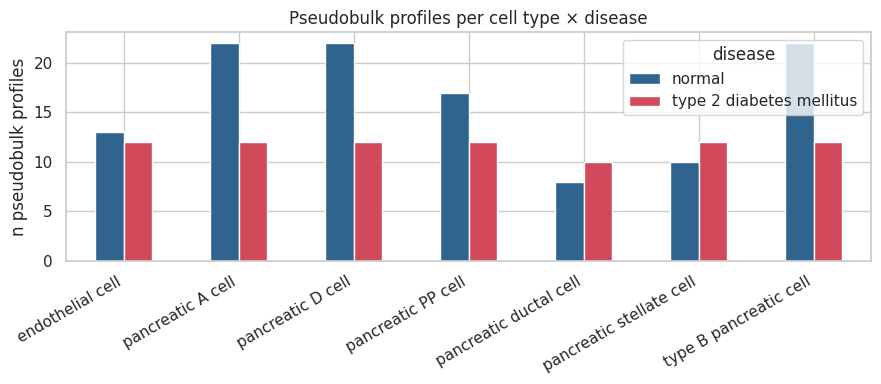

In [7]:
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
DPAL = {"normal": "#30638e", "type 2 diabetes mellitus": "#d1495b"}

comp = pd.crosstab(pb_meta["cell_type"], pb_meta["disease"])
print("Pseudobulk profiles per cell type × disease:\n")
print(comp.to_string())
n_norm = pb_meta[pb_meta.disease == "normal"]["donor_id"].nunique()
n_t2d  = pb_meta[pb_meta.disease != "normal"]["donor_id"].nunique()
print(f"\nTotal profiles: {len(pb_meta)} | donors: {pb_meta['donor_id'].nunique()} "
      f"(normal {n_norm}, T2D {n_t2d})")

ax = comp.plot(kind="bar", figsize=(9, 4),
               color=[DPAL.get(c, "#888") for c in comp.columns])
ax.set_ylabel("n pseudobulk profiles"); ax.set_xlabel("")
ax.set_title("Pseudobulk profiles per cell type × disease")
plt.xticks(rotation=30, ha="right"); plt.legend(title="disease")
plt.tight_layout(); plt.show()

### Per-profile QC — cells aggregated, library size, gene detection

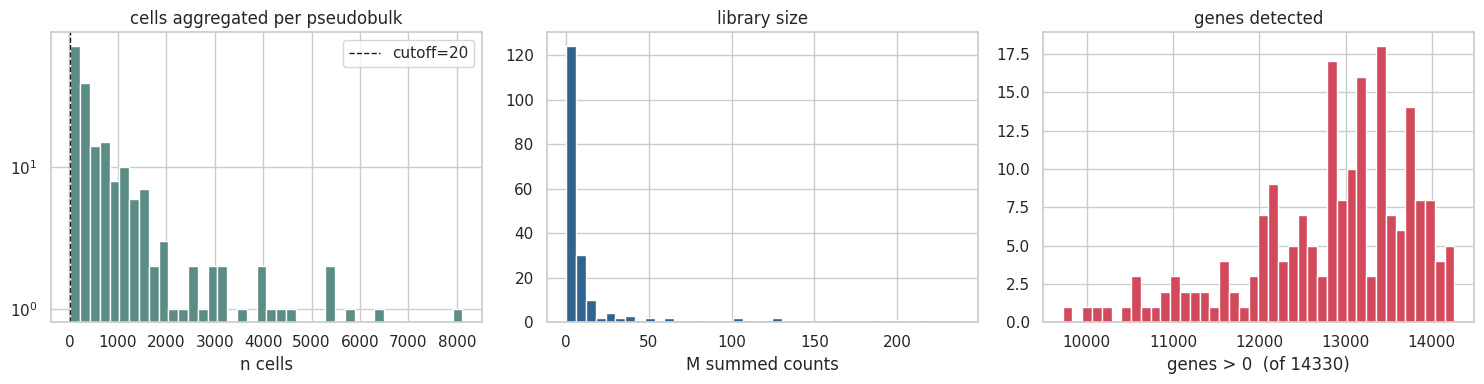

cells per pseudobulk:
 count     196.0
mean      846.0
std      1271.0
min        23.0
25%       136.0
50%       319.0
75%       972.0
max      8114.0


In [8]:
lib       = pb_counts.sum(axis=0)
genes_det = (pb_counts > 0).sum(axis=0)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(pb_meta["n_cells"], bins=40, color="#5b8c85"); ax[0].set_yscale("log")
ax[0].axvline(MIN_CELLS, color="k", ls="--", lw=1, label=f"cutoff={MIN_CELLS}")
ax[0].set_title("cells aggregated per pseudobulk"); ax[0].set_xlabel("n cells"); ax[0].legend()
ax[1].hist(lib/1e6, bins=40, color="#30638e")
ax[1].set_title("library size"); ax[1].set_xlabel("M summed counts")
ax[2].hist(genes_det, bins=40, color="#d1495b")
ax[2].set_title("genes detected"); ax[2].set_xlabel(f"genes > 0  (of {pb_counts.shape[0]})")
plt.tight_layout(); plt.show()

print("cells per pseudobulk:\n", pb_meta["n_cells"].describe().round(0).to_string())

### The two axes of variation: cell type vs disease

Your stated concern is that this dataset carries **two** structured sources of variation.
A PCA of the pseudobulk profiles makes them visible, and a simple variance partition
quantifies how much of the expression variance each factor explains.

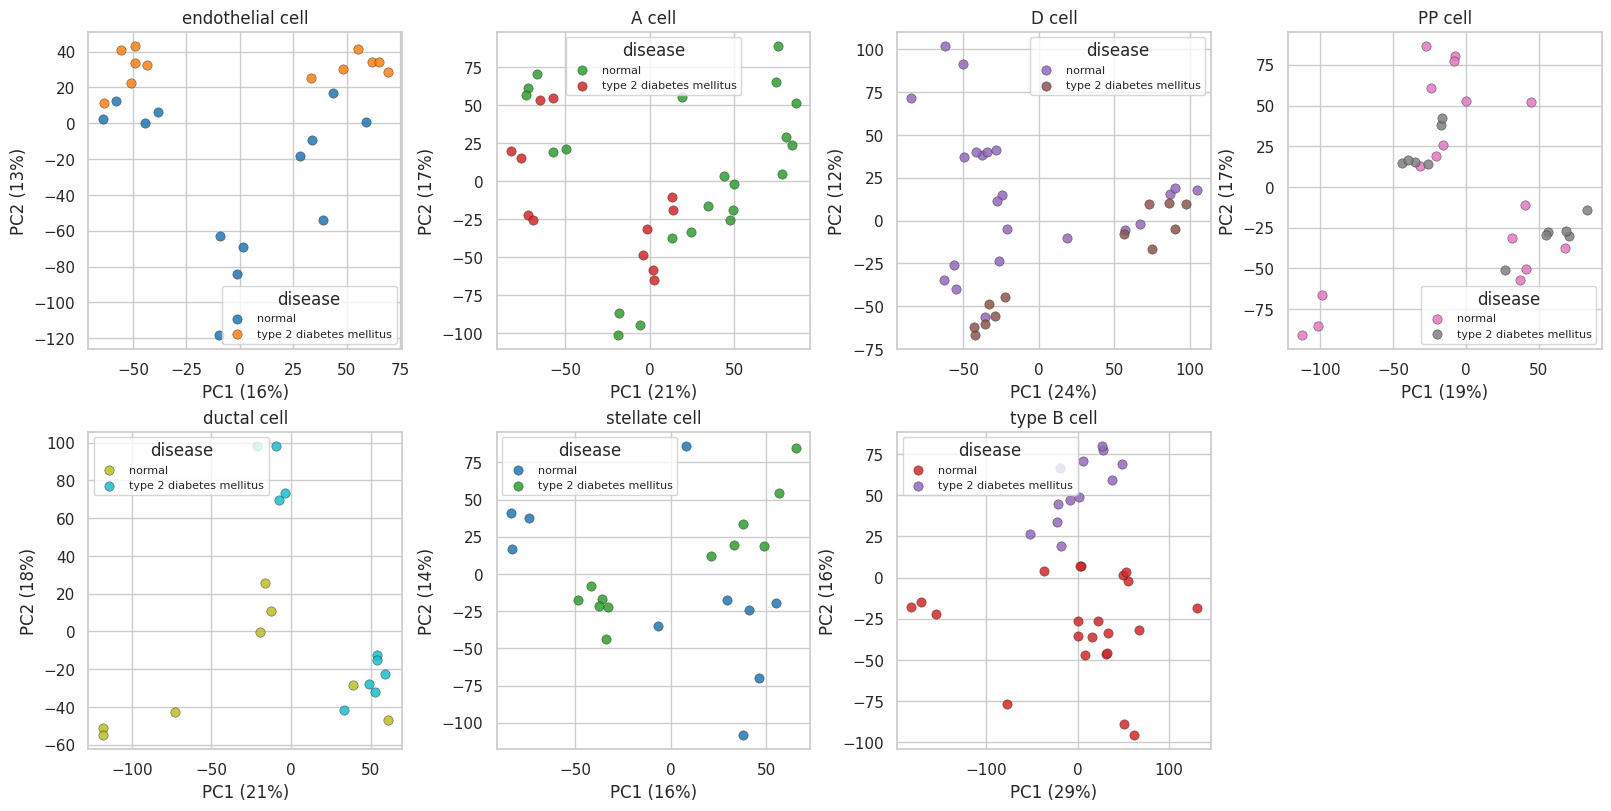

In [9]:
from gea.preprocessing import normalize_counts
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

norm = normalize_counts(pb_counts)                     # samples × genes, log2(CPM+1)
m    = pb_meta.set_index("sample_id").loc[norm.index]  # align metadata to matrix rows

ct_names = sorted(m["cell_type"].unique())
diseases = sorted(m["disease"].unique())

# Create distinct color palettes for each subplot
color_schemes = [
    {"normal": "#1f77b4", "type 2 diabetes mellitus": "#ff7f0e"},  # blue, orange
    {"normal": "#2ca02c", "type 2 diabetes mellitus": "#d62728"},  # green, red
    {"normal": "#9467bd", "type 2 diabetes mellitus": "#8c564b"},  # purple, brown
    {"normal": "#e377c2", "type 2 diabetes mellitus": "#7f7f7f"},  # pink, gray
    {"normal": "#bcbd22", "type 2 diabetes mellitus": "#17becf"},  # yellow-green, cyan
    {"normal": "#1f77b4", "type 2 diabetes mellitus": "#2ca02c"},  # blue, green
    {"normal": "#d62728", "type 2 diabetes mellitus": "#9467bd"},  # red, purple
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
axes = axes.ravel()

for i, ct in enumerate(ct_names):
    ax = axes[i]
    sel = m["cell_type"] == ct
    X_ct = norm.loc[sel].values
    Xs_ct = StandardScaler().fit_transform(X_ct)
    pca_ct = PCA(n_components=2, random_state=42).fit(Xs_ct)
    XP_ct = pca_ct.transform(Xs_ct)

    ct_meta = m.loc[sel]
    palette = color_schemes[i]

    for d in diseases:
        sel_d = ct_meta["disease"] == d
        ax.scatter(
            XP_ct[sel_d, 0],
            XP_ct[sel_d, 1],
            s=45,
            alpha=0.85,
            color=palette[d],
            edgecolor="k",
            linewidth=0.3,
            label=d,
        )

    ax.set_title(ct.replace("pancreatic ", ""))
    ax.set_xlabel(f"PC1 ({pca_ct.explained_variance_ratio_[0]:.0%})")
    ax.set_ylabel(f"PC2 ({pca_ct.explained_variance_ratio_[1]:.0%})")
    ax.legend(fontsize=8, title="disease")

for j in range(len(ct_names), len(axes)):
    axes[j].set_visible(False)

plt.show()

## LIONESS + PPI network construction

We now apply the GEA framework — z-space LIONESS with a STRING PPI prior — to the pseudobulk
profiles, mirroring the IBD tutorial with three deliberate choices:

- **Grouping variable = `cell_type`.** LIONESS builds its background co-expression network per
  group. Grouping by cell type (not by the label) keeps the aggregate network blind to disease,
  which avoids the per-group label-leakage failure mode. Each sample's network is then its
  leave-one-out deviation from its own cell type's background.
- **Two graph-level labels:** `disease` (primary phenotype objective) and `cell_type` (second
  objective). Both are attached to every graph.
- **Mouse adaptations:** STRING `species=10090`, `mygene species='mouse'`, and we do **not** call
  `filter_protein_coding` (hard-coded to human `ENSG…`; QC was already done upstream).

In [10]:
# ── Resume point ────────────────────────────────────────────────────────────
# Lets you run the modelling section without re-fetching CELLxGENE: if the
# pseudobulk objects aren't in memory, reload them from the saved artefacts.
import pandas as pd
try:
    pb_counts, pb_meta
except NameError:
    pb_counts = pd.read_csv("data/t2d/tutorial-t2d-pseudobulk-matrix.tsv", sep="\t", index_col="Geneid")
    pb_meta   = pd.read_csv("data/t2d/tutorial-t2d-pseudobulk-metadata.csv")
    print("(resumed) reloaded pseudobulk from disk")
print(f"Pseudobulk: {pb_counts.shape[0]} genes × {pb_counts.shape[1]} samples")

Pseudobulk: 14330 genes × 196 samples


### Gene filtering + STRING PPI prior (mouse)

In [11]:
from gea.preprocessing import filter_genes

# Same abundance + variance filter as the IBD tutorial: keep highly expressed,
# high-variance genes so the co-expression matrices are tractable and informative.
filt_counts = filter_genes(pb_counts, cpm_threshold=1, min_frac=0.1, pct=0.1)
print(f"CPM + variance filter: {pb_counts.shape[0]} → {filt_counts.shape[0]} genes")

CPM + variance filter: 14330 → 1382 genes


In [12]:
import mygene

# Ensembl (ENSMUSG) → gene symbol, needed to query STRING. species='mouse' (not human!).
mg = mygene.MyGeneInfo()
info = mg.querymany(filt_counts.index.tolist(), scopes="ensembl.gene",
                    fields="symbol", species="mouse", as_dataframe=True, verbose=False)
info = info[~info.index.duplicated(keep="first")]
ensembl_to_symbol = info["symbol"].dropna().to_dict()
print(f"Mapped {len(ensembl_to_symbol)}/{filt_counts.shape[0]} genes to mouse symbols")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Mapped 1382/1382 genes to mouse symbols


In [13]:
from gea.dataloader import load_string_ppi_network
from gea.utils import get_gene_list

# species=10090 = Mus musculus. ensembl_to_symbol lets STRING be queried with symbols
# and enriches the returned network with ensemblId_A / ensemblId_B columns.
gene_list = get_gene_list(filt_counts)          # ENSMUSG IDs
ppi_network = load_string_ppi_network(
    gene_list, species=10090, conf_score=600, ensembl_to_symbol=ensembl_to_symbol,
)
print(ppi_network[["preferredName_A", "preferredName_B", "score"]].head())

Successfully retrieved PPI network!
Found 5697 interactions.
  preferredName_A preferredName_B  score
0            Cav2            Ehd2  0.614
1            Cav2           Itgb6  0.650
2            Cav2          Cavin3  0.685
3            Cav2          Cavin2  0.688
4            Cav2           Itgb4  0.696


In [14]:
from gea.preprocessing import filter_ppi_nodes

# Keep only genes that appear in the PPI network — these become the graph nodes.
filt_counts_ppi = filter_ppi_nodes(filt_counts, ppi_network)
print(f"Genes retained in PPI network: {filt_counts.shape[0]} → {filt_counts_ppi.shape[0]}")

Genes retained in PPI network: 1382 → 1030


### Node embeddings — mouse ESM-2 (identical procedure to the IBD tutorial)

Node features are `[expression | ESM-2 protein embedding]`. The gene list was exported to
`data/t2d/ensembl_ids_t2d.txt` and embeddings were computed **exactly as in the IBD tutorial** with
`scripts/get_esm_embeddings.py` — same ESM-2 model (`facebook/esm2_t33_650M_UR50D`), CLS-token
representation, isoforms aggregated by mean — only pointed at the **mouse** proteome
(`Mus_musculus.GRCm39.pep.all`, `--fasta data/t2d/mouse_pep.fa.gz`). We then compress 1280→256 dims
with whitened PCA, as in IBD.

In [15]:
from gea.utils import load_esm_embeddings, compress_embeddings_pca, get_gene_list

# Node order must match the graph gene order = columns of the normalised matrix = filt_counts_ppi.index
gene_list_ppi = get_gene_list(filt_counts_ppi)

# Load pre-computed mouse ESM-2 embeddings (mean over isoforms), then PCA-compress + L2-renorm.
esm_embeddings = load_esm_embeddings(
    esm_file="data/t2d/esm_embeddings_t2d.pt", ensembl_ids=gene_list_ppi, aggregation="mean",
)
esm_embeddings = compress_embeddings_pca(esm_embeddings, n_components=256, whiten=True)
print(f"ESM-2 embedding matrix after PCA: {tuple(esm_embeddings.shape)}  (genes × 256)")

Loading ESM-2 embeddings: 100%|██████████| 1030/1030 [00:00<00:00, 29194.43it/s]

Found ESM-2 embeddings for 1030/1030 genes.


PCA: 1280→256 dims, 95.1% variance retained.
ESM-2 embedding matrix after PCA: (1030, 256)  (genes × 256)


### Normalize counts and assemble the joint matrix

In [16]:
from gea.preprocessing import normalize_counts

# log2(CPM+1); returns samples × genes. Then attach the grouping var (cell_type)
# and both labels (disease, cell_type) — merge_metadata is bypassed because we
# already hold the metadata.
norm_counts = normalize_counts(filt_counts_ppi)
joint_data  = norm_counts.join(
    pb_meta.set_index("sample_id")[["cell_type", "disease"]]
)
print(f"joint_data: {joint_data.shape}  (samples × [genes + cell_type + disease])")
print(joint_data["disease"].value_counts().to_string())

joint_data: (196, 1032)  (samples × [genes + cell_type + disease])
disease
normal                      114
type 2 diabetes mellitus     82


### Gene co-expression per cell type + z-space LIONESS with the PPI prior

In [17]:
from gea.preprocessing import get_corr_matrix, lioness_ppi

# One aggregate co-expression matrix per cell type (the LIONESS background).
gene_corrs, grouped_data = get_corr_matrix(joint_data, group_by="cell_type")
print(f"{len(grouped_data)} cell-type groups; sample counts per group:",
      [gd.shape[0] for gd in grouped_data])

# For each cell type, LIONESS derives a sample-specific network per profile, keeping only
# PPI edges whose |correlation| exceeds the threshold.
sample_networks = lioness_ppi(grouped_data, gene_corrs, ppi_network, threshold=0.25)
print(f"Built {len(sample_networks)} sample-specific networks")

7 cell-type groups; sample counts per group: [22, 29, 34, 34, 34, 25, 18]


LIONESS samples (PPI filtered) for group 7/7: 100%|██████████| 18/18 [00:00<00:00, 20.45it/s]

Built 196 sample-specific networks


### Convert to PyG graphs with two labels

`bio_col='disease'` sets the primary graph label `y`; `bio_col2='cell_type'` attaches the second
label `y_ct` used by the cell-type objective. `standardize_expr` z-scores each gene's expression
across samples (same as IBD).

In [18]:
from gea.preprocessing import gene_networks_to_pyg
import torch

t2d_graphs = gene_networks_to_pyg(
    sample_networks, joint_data, esm_embeddings,
    bio_col="disease", bio_col2="cell_type", standardize_expr=True,
)
torch.save(t2d_graphs, "data/t2d/t2d_graphs.pt")
print(f"Built and saved {len(t2d_graphs)} PyG graphs → data/t2d/t2d_graphs.pt")
print(f"Node feature dim: {t2d_graphs[0].x.shape[1]}  (1 expr + 256 ESM-2 PCA)")
print("Has y (disease):", hasattr(t2d_graphs[0], "y"), "| has y_ct (cell type):", hasattr(t2d_graphs[0], "y_ct"))

Building PyG Data objects for sample-specific networks: 100%|██████████| 196/196 [00:26<00:00,  7.39it/s]


Built and saved 196 PyG graphs → data/t2d/t2d_graphs.pt
Node feature dim: 257  (1 expr + 256 ESM-2 PCA)
Has y (disease): True | has y_ct (cell type): True


### Graph statistics

Graphs        : 196
Nodes / graph : 1030  |  feature dim: 257
Directed edges/graph: min 7038, mean 8773, max 10562  | pos-edge 69.2%
Disease labels : {'normal': 114, 'type 2 diabetes mellitus': 82}
Cell-type labels: {'endothelial cell': 25, 'pancreatic A cell': 34, 'pancreatic D cell': 34, 'pancreatic PP cell': 29, 'pancreatic ductal cell': 18, 'pancreatic stellate cell': 22, 'type B pancreatic cell': 34}


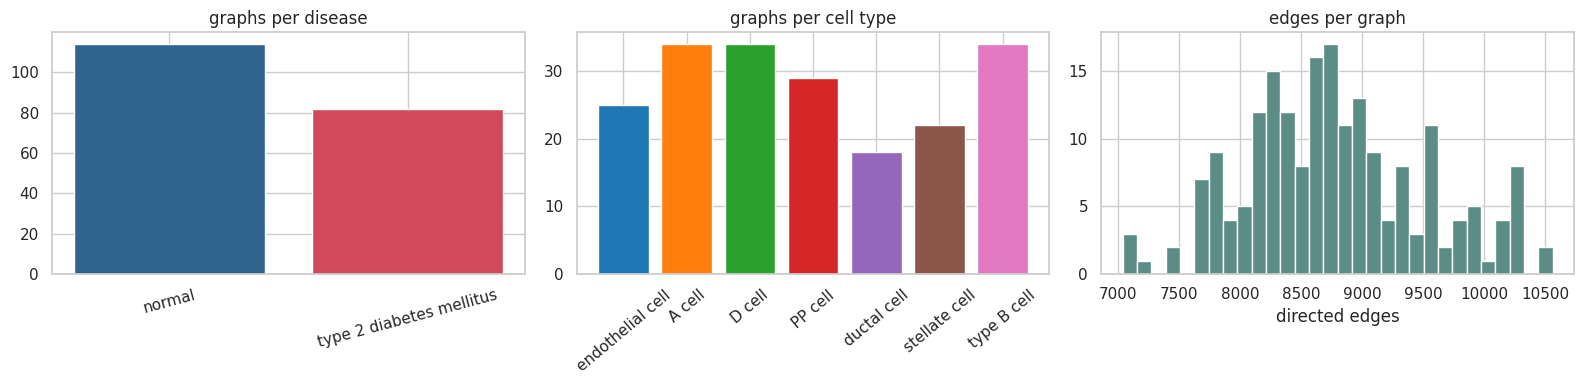

In [19]:
import numpy as np, collections, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

disease_names = sorted(joint_data["disease"].unique())     # label int → name
ct_names      = sorted(joint_data["cell_type"].unique())
y    = np.array([g.y.item() for g in t2d_graphs])
y_ct = np.array([g.y_ct.item() for g in t2d_graphs])
ne   = np.array([g.edge_index.shape[1] for g in t2d_graphs])
pos_frac = np.array([(g.edge_type == 0).float().mean().item() for g in t2d_graphs])

print(f"Graphs        : {len(t2d_graphs)}")
print(f"Nodes / graph : {t2d_graphs[0].x.shape[0]}  |  feature dim: {t2d_graphs[0].x.shape[1]}")
print(f"Directed edges/graph: min {ne.min()}, mean {ne.mean():.0f}, max {ne.max()}  | pos-edge {pos_frac.mean():.1%}")
print("Disease labels :", {disease_names[k]: int(v) for k, v in sorted(collections.Counter(y).items())})
print("Cell-type labels:", {ct_names[k]: int(v) for k, v in sorted(collections.Counter(y_ct).items())})

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar([disease_names[k] for k in sorted(set(y))],
          [ (y==k).sum() for k in sorted(set(y)) ], color=["#30638e", "#d1495b"])
ax[0].set_title("graphs per disease"); ax[0].tick_params(axis="x", rotation=15)
ax[1].bar([ct_names[k].replace("pancreatic ", "") for k in sorted(set(y_ct))],
          [ (y_ct==k).sum() for k in sorted(set(y_ct)) ], color=sns.color_palette("tab10", len(ct_names)))
ax[1].set_title("graphs per cell type"); ax[1].tick_params(axis="x", rotation=40)
ax[2].hist(ne, bins=30, color="#5b8c85"); ax[2].set_title("edges per graph"); ax[2].set_xlabel("directed edges")
plt.tight_layout(); plt.show()

## Training the multi-task GNN

Trained **exactly as in `tutorial-ibd.ipynb`** (same `GNNModel`, same `train_gnn`, stratified
80/20 split, `input_proj_dim=None`, 200 epochs), with one addition: a **second graph-level
objective**. The model now optimises three losses jointly:

1. **Disease** classification (`normal` vs `T2D`) — primary phenotype head,
2. **Cell type** classification (7 classes) — second head (`n_classes_ct=7`),
3. **Edge-weight** prediction — the self-supervised co-expression objective.

> The split is stratified by disease to match the IBD procedure. ⚠ For a rigorous evaluation use
> a **donor-grouped** split (profiles from one donor across cell types must not straddle
> train/test); here we keep IBD's procedure for a like-for-like comparison.

In [20]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

# Stratified 80/20 split by disease (same as IBD, which stratified by its phenotype label).
train_graphs, test_graphs = train_test_split(
    t2d_graphs, test_size=0.2, random_state=42, stratify=[g.y.item() for g in t2d_graphs],
)
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_graphs,  batch_size=32, shuffle=False)
embed_loader = DataLoader(t2d_graphs,   batch_size=32, shuffle=False)   # all graphs, for SAE/GEA later
print(f"Train: {len(train_graphs)} | Test: {len(test_graphs)} graphs")

Train: 156 | Test: 40 graphs


In [21]:
from gea.gea import set_seed, GNNModel
import torch

set_seed(42)  # reproducible weight init
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

in_dim       = t2d_graphs[0].x.shape[1]                       # 1 expr + 256 ESM-2 PCA
n_classes    = len(sorted({g.y.item() for g in t2d_graphs}))  # 2: normal, T2D
n_classes_ct = len(sorted({g.y_ct.item() for g in t2d_graphs}))  # 7 cell types
d_z          = 128

gnn = GNNModel(
    in_channels=in_dim,
    n_classes=n_classes,
    n_classes_ct=n_classes_ct,     # <-- enables the second (cell-type) head
    latent_dim=d_z,
    input_proj_dim=None,
).to(device)
print(f"Node feature dim: {in_dim} | disease classes: {n_classes} | cell-type classes: {n_classes_ct}")

Node feature dim: 257 | disease classes: 2 | cell-type classes: 7


In [22]:
from gea.gea import train_gnn

train_gnn(
    model=gnn,
    train_loader=train_loader,
    device=device,
    epochs=200,
    lr=1e-3,
    w_l2=1e-4,
    w_classifier=1.0,      # disease loss weight
    w_edge_pred=0.5,       # edge-weight loss weight
    w_classifier_ct=1.0,   # cell-type loss weight (second objective)
    val_loader=test_loader,
)

Training GNN model: 100%|██████████| 1000/1000 [01:02<00:00, 15.94it/s, acc=98.72%, acc_ct=100.00%, epoch=200/200, loss=0.0697, val_acc=85.00%, val_acc_ct=95.00%, val_loss=0.4059]


### Evaluation — both objectives on the held-out test set

── Disease (normal vs T2D) ──
  balanced acc 0.919 | macro-F1 0.923
── Cell type (7 classes) ──
  balanced acc 0.944 | macro-F1 0.946


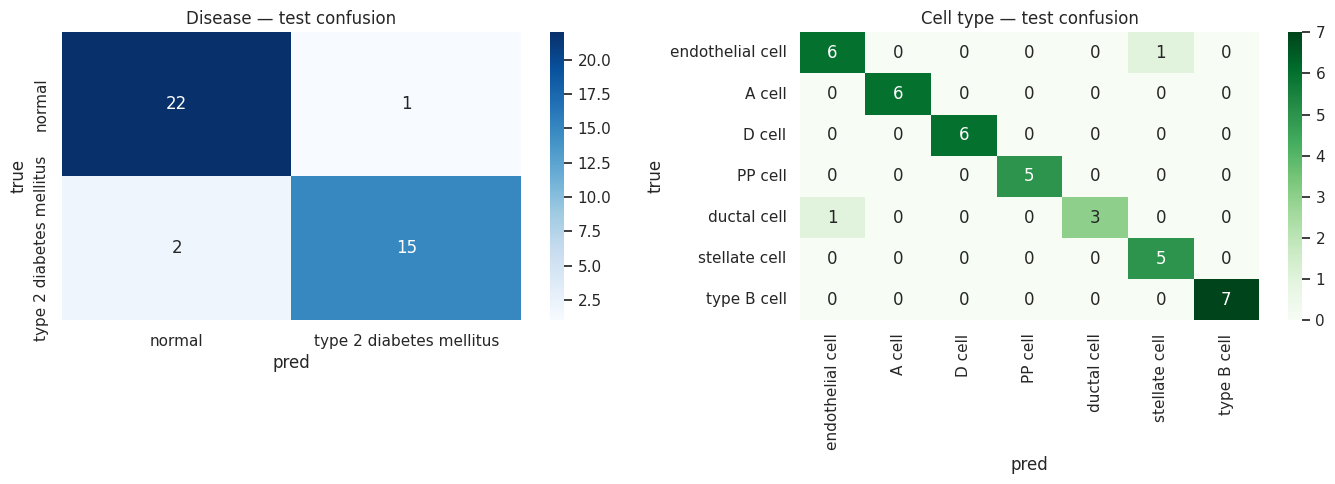

In [23]:
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix
import numpy as np, matplotlib.pyplot as plt, seaborn as sns

gnn.eval()
yd_true, yd_pred, yc_true, yc_pred = [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, pred_class, pred_class_ct = gnn(batch)
        yd_true += batch.y.cpu().tolist();    yd_pred += pred_class.argmax(-1).cpu().tolist()
        yc_true += batch.y_ct.cpu().tolist(); yc_pred += pred_class_ct.argmax(-1).cpu().tolist()

print("── Disease (normal vs T2D) ──")
print(f"  balanced acc {balanced_accuracy_score(yd_true, yd_pred):.3f} | "
      f"macro-F1 {f1_score(yd_true, yd_pred, average='macro'):.3f}")
print("── Cell type (7 classes) ──")
print(f"  balanced acc {balanced_accuracy_score(yc_true, yc_pred):.3f} | "
      f"macro-F1 {f1_score(yc_true, yc_pred, average='macro'):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(yd_true, yd_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=disease_names, yticklabels=disease_names, ax=ax[0])
ax[0].set_title("Disease — test confusion"); ax[0].set_xlabel("pred"); ax[0].set_ylabel("true")
sns.heatmap(confusion_matrix(yc_true, yc_pred), annot=True, fmt="d", cmap="Greens",
            xticklabels=[c.replace("pancreatic ", "") for c in ct_names],
            yticklabels=[c.replace("pancreatic ", "") for c in ct_names], ax=ax[1])
ax[1].set_title("Cell type — test confusion"); ax[1].set_xlabel("pred"); ax[1].set_ylabel("true")
plt.tight_layout(); plt.show()

### Graph-embedding PCA (coloured by disease and by cell type)

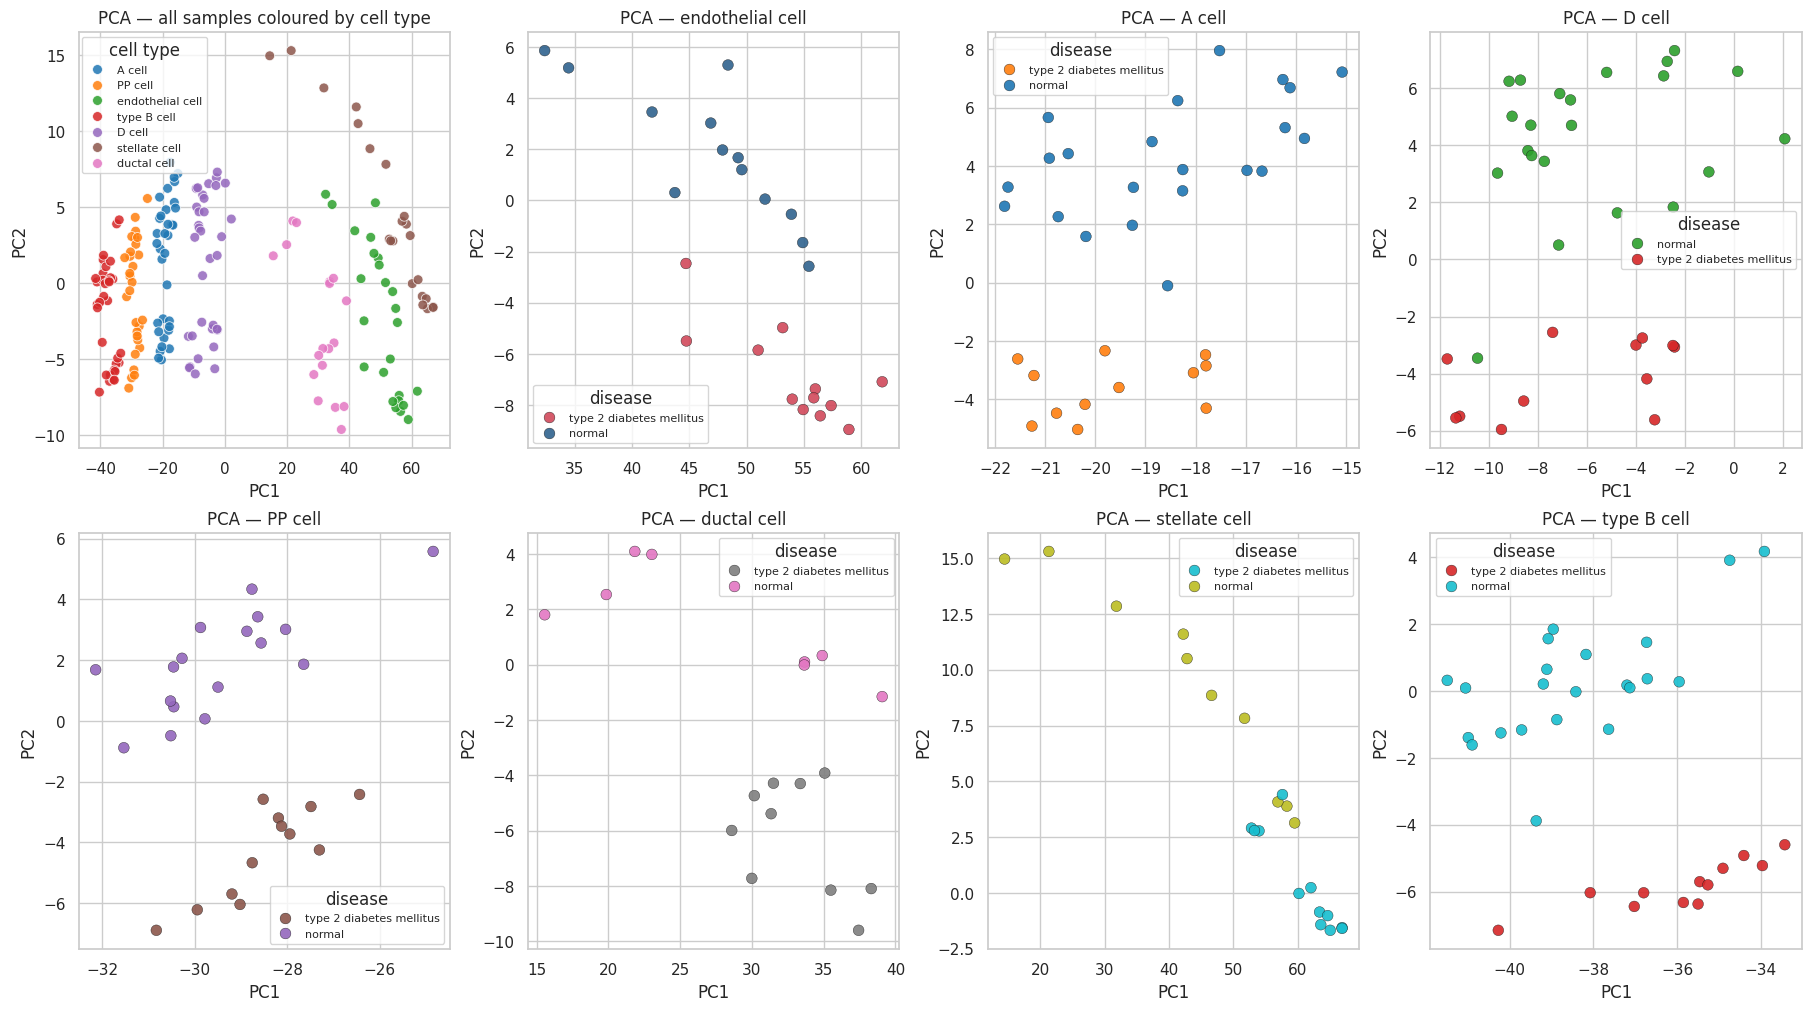

In [24]:
from sklearn.decomposition import PCA

gnn.eval()
Z, zy, zyc = [], [], []
with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)
        _, z_graph = gnn.encode(batch)
        Z.append(z_graph.cpu().numpy())
        zy.extend(batch.y.cpu().tolist())
        zyc.extend(batch.y_ct.cpu().tolist())

    for batch in test_loader:
        batch = batch.to(device)
        _, z_graph = gnn.encode(batch)
        Z.append(z_graph.cpu().numpy())
        zy.extend(batch.y.cpu().tolist())
        zyc.extend(batch.y_ct.cpu().tolist())

Z = np.concatenate(Z, axis=0)
coords = PCA(n_components=2, random_state=42).fit_transform(Z)

cell_type_short = [ct.replace("pancreatic ", "") for ct in ct_names]
df = pd.DataFrame(coords, columns=["PC1", "PC2"])
df["disease"] = [disease_names[i] for i in zy]
df["cell_type"] = [cell_type_short[i] for i in zyc]

disease_palettes = [
    {"normal": "#30638e", "type 2 diabetes mellitus": "#d1495b"},
    {"normal": "#1f77b4", "type 2 diabetes mellitus": "#ff7f0e"},
    {"normal": "#2ca02c", "type 2 diabetes mellitus": "#d62728"},
    {"normal": "#9467bd", "type 2 diabetes mellitus": "#8c564b"},
    {"normal": "#e377c2", "type 2 diabetes mellitus": "#7f7f7f"},
    {"normal": "#bcbd22", "type 2 diabetes mellitus": "#17becf"},
    {"normal": "#17becf", "type 2 diabetes mellitus": "#d62728"},
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10), constrained_layout=True)
axes = axes.ravel()

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette=sns.color_palette("tab10", len(cell_type_short)),
    s=50,
    alpha=0.85,
    ax=axes[0],
)
axes[0].set_title("PCA — all samples coloured by cell type")
axes[0].legend(title="cell type", fontsize=8, bbox_to_anchor=(0.36, 1), loc="upper right")

for i, ct in enumerate(cell_type_short):
    ax = axes[i + 1]
    subset = df[df["cell_type"] == ct]
    sns.scatterplot(
        data=subset,
        x="PC1",
        y="PC2",
        hue="disease",
        palette=disease_palettes[i],
        s=60,
        alpha=0.9,
        edgecolor="k",
        linewidth=0.3,
        ax=ax,
    )
    ax.set_title(f"PCA — {ct}")
    ax.legend(title="disease", fontsize=8)

plt.show()

## Applying `GEA` to trained model's embeddings

### Extracting embeddings

In [25]:
from gea.gea import export_embeddings

emb_paths = export_embeddings(
    gnn,
    embed_loader,
    device,
    out_dir="data/t2d",
    prefix="t2d_emb",
    gene_names=gene_list_ppi,   # node order the graphs were built with
    label_names=disease_names,
    ct_names=ct_names,
    # dtype=np.float16,         # halves the ~790 MB node+edge footprint
)

Extracting graph-level embeddings: 100%|██████████| 7/7 [00:00<00:00, 36.15it/s]


graph-level:       196 rows × 128 dims → data/t2d/t2d_emb_graph.npz


Extracting node-level embeddings: 100%|██████████| 7/7 [00:00<00:00,  7.92it/s]


 node-level:   201,880 rows × 128 dims → data/t2d/t2d_emb_node.npz


Extracting edge-level embeddings: 100%|██████████| 7/7 [00:03<00:00,  2.11it/s]


 edge-level:   859,724 rows × 128 dims → data/t2d/t2d_emb_edge.npz


### EmbeddingDataset class

In [26]:
from torch.utils.data import DataLoader as EmbeddingLoader
from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed

graph_emb = EmbeddingDataset(emb_paths["graph"])
node_emb = EmbeddingDataset(emb_paths["node"])
edge_emb = EmbeddingDataset(emb_paths["edge"])

In [27]:
for emb in graph_emb:
    print(emb)
    break

{'embedding': tensor([ -2.8075,  -1.4669,  -1.4265,   4.5198,  -1.7861,   8.4780,  -3.5389,
         15.3178, -11.0521,   4.2306,  12.9410, -11.4074,  -3.0408,  -1.3898,
          1.3517,   1.3860,   6.1396, -10.9379,  -1.4183,   4.1945,   3.9836,
          2.2577,  -4.2829,  -1.6326,  -3.3991, -12.9581,  -6.9845,  -1.7258,
         -2.0820,  -9.6685,   0.0615,  -0.0656,  -9.6852, -14.2378,  -1.8785,
         -5.5981,  -6.7228,   1.1757,  12.5508,   3.0550,  10.5552,  -0.9380,
         -1.0377,  -2.8560,  -2.5959,  11.9747,   4.9854,  -0.8605,  -1.8043,
         -7.4600,   9.4197,  -9.9316,   1.3792,   2.1804,   0.1984,  -6.5151,
        -10.6470,  -4.7296,  -1.9562,   8.2467,  -3.6240,  -2.9976,   8.8912,
          4.7869,  -1.5493,  14.8630,  -0.3575,  -3.1121,  -1.2178,   4.1157,
          8.0430,   0.3178,  -0.1723,  -3.2145,   1.2113,  13.5251,   2.9383,
         -1.0934,   3.2049,   9.3038,  -0.2745,  -9.7518,  -0.1257,   0.2393,
         -0.7544,  -6.2335,  -6.1218,   1.4272,  -

### Training graph-level SAE

In [28]:
from torch.utils.data import DataLoader as EmbeddingLoader

from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed, ShallowSAE, train_sae

set_seed(42)  # reproducible weight init

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# One embedding per graph, carrying its sample name, phenotype and cell type
graph_emb = EmbeddingDataset(emb_paths["graph"])
print(f"{len(graph_emb):,} graph embeddings of dim {graph_emb[0]['embedding'].shape[0]}")
print("annotations (biological groups, one-hot):",
      {k: v.tolist() for k, v in graph_emb[0]["annotation"].items()})

sae_graph = ShallowSAE(in_dim=d_z, latent_dim=d_z * 8, sparsity_weight=1e-3).to(device)

train_sae(
    sae_model=sae_graph,
    train_loader=EmbeddingLoader(graph_emb, batch_size=32, shuffle=True),
    device=device,
    epochs=500,
    w_l2 = 0,
)

196 graph embeddings of dim 128
annotations (biological groups, one-hot): {'disease': [1.0, 0.0], 'cell_type': [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]}


Training SAE model: 100%|██████████| 3500/3500 [00:12<00:00, 283.96it/s, epoch=499/501, total_loss=0.0604]


### Training node-level SAE

In [29]:
from torch.utils.data import DataLoader as EmbeddingLoader

from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed, ShallowSAE, train_sae

set_seed(42)  # reproducible SAE weight init

# One embedding per (graph, gene). Each row knows which gene of which graph it is.
node_emb = EmbeddingDataset(emb_paths["node"])
print(f"{len(node_emb):,} node embeddings — e.g. {node_emb[0]['entity']}")

sae_node = ShallowSAE(in_dim=d_z, latent_dim=d_z * 8, sparsity_weight=1e-2).to(device)

# Batch size and epoch count differ from the graph-level SAE because an epoch here
# is ~1,000× more rows: 30 epochs of 4,096-row batches is ~1.5k updates (~2 min on
# CPU), already more than the graph-level SAE sees in 100 epochs.
train_sae(
    sae_model=sae_node,
    train_loader=EmbeddingLoader(node_emb, batch_size=4096, shuffle=True, num_workers=4),
    device=device,
    epochs=100,
    w_l2 = 0,
)

201,880 node embeddings — e.g. mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610296|pancreatic_stellate_cell|normal::ENSMUSG00000074896


Training SAE model: 100%|██████████| 5000/5000 [07:11<00:00, 11.60it/s, epoch=99/101, total_loss=0.8559]


### Training edge-level SAE

In [30]:
from torch.utils.data import DataLoader as EmbeddingLoader

from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed, ShallowSAE, train_sae

set_seed(42)  # reproducible SAE weight init

# One embedding per (graph, gene pair). The signed co-expression weight is kept as
# an annotation, so a feature can later be traced to positively vs negatively
# correlated pairs.
edge_emb = EmbeddingDataset(emb_paths["edge"])
print(f"{len(edge_emb):,} edge embeddings — e.g. {edge_emb[0]['entity']} "
      f"(weight {edge_emb[0]['annotation']['weight']:+.3f})")

sae_edge = ShallowSAE(in_dim=d_z, latent_dim=d_z * 8, sparsity_weight=1e-3).to(device)

# ~860k rows per epoch → 20 epochs is ~4.2k updates (~6 min on CPU).
train_sae(
    sae_model=sae_edge,
    train_loader=EmbeddingLoader(edge_emb, batch_size=4096, shuffle=True, num_workers=4),
    device=device,
    epochs=100,
    w_l2 = 0,
)

859,724 edge embeddings — e.g. mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610296|pancreatic_stellate_cell|normal::ENSMUSG00000001131--ENSMUSG00000037405 (weight +0.389)


Training SAE model: 100%|██████████| 21000/21000 [28:12<00:00, 12.41it/s, epoch=99/101, total_loss=0.0728]


### Saving model checkpoints

In [31]:
import torch
from pathlib import Path

ckpt_path = Path("data/t2d/t2d_checkpoints.pt")
ckpt_path.parent.mkdir(parents=True, exist_ok=True)


def weights(model):
    """State dict on CPU, so a checkpoint trained on GPU still loads on a CPU box."""
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}


def sae_config(sae):
    return dict(in_dim=sae.in_dim, latent_dim=sae.latent_dim,
                sparsity_weight=sae.sparsity_weight)


# Constructor kwargs travel with the weights so every model can be rebuilt without
# re-reading this notebook, and the gene / label order is kept because the weights
# are meaningless without it: node features are ordered by gene_list_ppi, and the
# y, y_ct and one-hot annotations are positions in disease_names / ct_names.
torch.save(
    {
        "gnn": {
            "state_dict": weights(gnn),
            "config": dict(in_channels=in_dim, n_classes=n_classes,
                           n_classes_ct=n_classes_ct, latent_dim=d_z,
                           input_proj_dim=None),
        },
        "sae_graph": {"state_dict": weights(sae_graph), "config": sae_config(sae_graph)},
        "sae_node": {"state_dict": weights(sae_node), "config": sae_config(sae_node)},
        "sae_edge": {"state_dict": weights(sae_edge), "config": sae_config(sae_edge)},
        "gene_order": gene_list_ppi,
        "disease_names": disease_names,
        "ct_names": ct_names,
        "embedding_paths": emb_paths,
        "seed": 42,
    },
    ckpt_path,
)
print(f"saved {ckpt_path} ({ckpt_path.stat().st_size / 1e6:.1f} MB)")

saved data/t2d/t2d_checkpoints.pt (4.7 MB)


### Realoding model checkpoints

In [32]:
import torch
from torch.utils.data import DataLoader as EmbeddingLoader

from gea.dataloader import EmbeddingDataset
from gea.gea import set_seed, ShallowSAE, train_sae

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load("data/t2d/t2d_checkpoints.pt", map_location=device, weights_only=False)

gnn = GNNModel(**ckpt["gnn"]["config"]).to(device)
gnn.load_state_dict(ckpt["gnn"]["state_dict"])

sae_graph = ShallowSAE(**ckpt["sae_graph"]["config"]).to(device)
sae_graph.load_state_dict(ckpt["sae_graph"]["state_dict"])

sae_node = ShallowSAE(**ckpt["sae_node"]["config"]).to(device)
sae_node.load_state_dict(ckpt["sae_node"]["state_dict"])

sae_edge = ShallowSAE(**ckpt["sae_edge"]["config"]).to(device)
sae_edge.load_state_dict(ckpt["sae_edge"]["state_dict"])

<All keys matched successfully>

### Clustered heatmap of graph-level SAE features

Alive: 20/1024 features (1004 dead or constant, dropped)


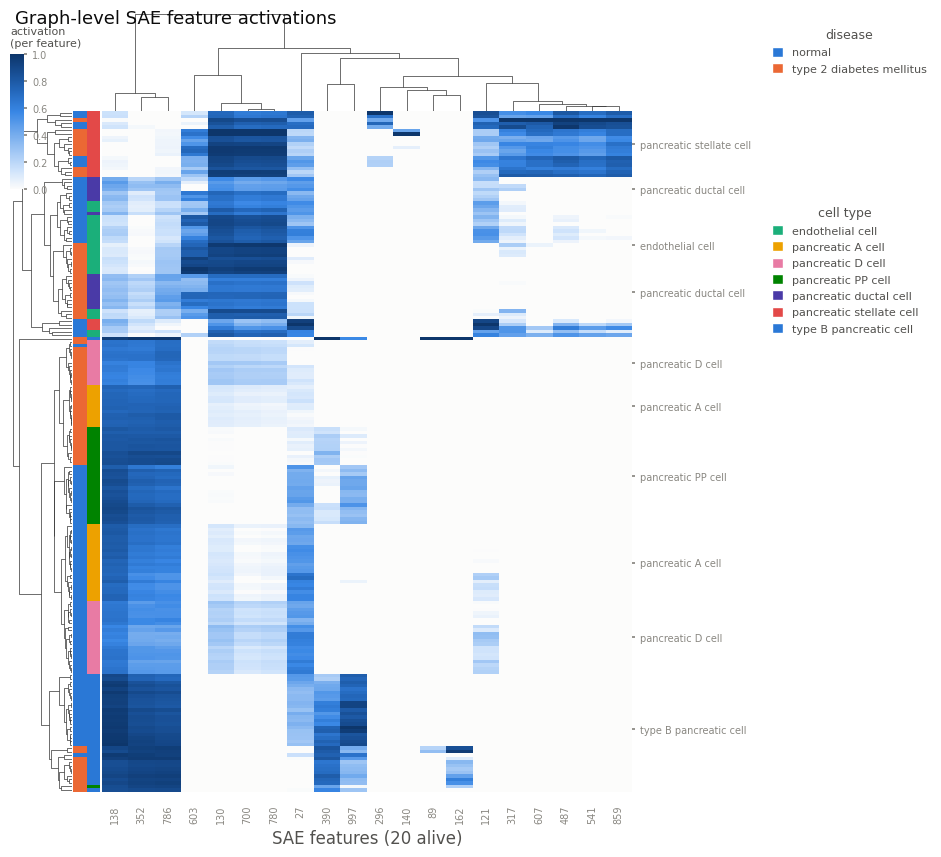

In [33]:
from gea.analysis import extract_sae_activations, plot_sae_feature_clustermap

# Activations of the trained graph-level SAE, one row per pseudobulk profile, with
# the identity from the embedding export attached (graph_id, disease, cell_type).
graph_acts_df = extract_sae_activations(sae_graph, emb_paths["graph"], device)

# Rows and features are both hierarchically clustered. Features that never fire —
# or fire in <5% of profiles — are dropped first: a dead feature cannot cluster and
# only flattens the colour scale. Each feature column is min-max scaled so that a
# couple of loud features do not wash out the rest (pass scale="none" for raw
# activation magnitudes).
g, alive_features = plot_sae_feature_clustermap(
    graph_acts_df,
    annotate=("disease", "cell_type"),   # one strip each, listed most-important first
    min_activation_frac=0.01,
)

# Contiguous blocks of clustered rows are labelled in text on the right, because
# seven cell-type hues cannot all be told apart by colour alone.
g.figure.savefig("data/t2d/t2d_sae_graph_clustermap.png", dpi=200,
                 bbox_inches="tight", facecolor="#fcfcfb")

## Annotating node-level SAE features with gene sets

The clustermap above says *which* graph-level features separate the profiles. It says nothing
about **what a feature means**. `gea_gene_nets.annotation_funcs` answers that for the
**node-level** SAE, following the same recipe `gea_molecules.annotation_funcs` uses for
molecules — only the concept vocabulary changes:

| molecules | gene networks |
|---|---|
| atom | gene (node) |
| motif dictionary `{name: SMARTS}` | gene-set library `{term: [symbols]}` |
| `motifAnnotation(mol, motifs)` | `geneSetAnnotation(gene_list, gene_sets)` |
| F1(motif \| feature) | F1(term \| feature) |

A node SAE feature is treated as a **binary classifier of gene-set membership**: threshold its
activation over the 1,030 genes of one graph and ask how well the genes it fires on coincide
with the genes of a pathway. The best-matching term, by F1, is that feature's annotation.

One difference drives the design. Molecules have different atoms; here **every graph shares the
same gene universe**, so term membership is a property of the gene and it is the activations that
vary between profiles. The scoring is therefore done **per graph** and then integrated — which is
the interesting part: a term a feature matches in all 196 profiles is a housekeeping concept, one
it only matches in the T2D beta-cell profiles is a phenotype-specific concept.

In [34]:
from gea_gene_nets.annotation_funcs import fetch_gene_sets, geneSetAnnotation, gene_set_matrix

# ── Resume point ────────────────────────────────────────────────────────────
# The node universe is the gene order the graphs were built with; after a kernel
# restart it travels in the checkpoint, and mygene gives back the symbols the
# Enrichr libraries are indexed by.
try:
    emb_paths, gene_list_ppi, ensembl_to_symbol
except NameError:
    import mygene
    emb_paths     = ckpt["embedding_paths"]
    gene_list_ppi = ckpt["gene_order"]
    info = mygene.MyGeneInfo().querymany(
        gene_list_ppi, scopes="ensembl.gene", fields="symbol",
        species="mouse", as_dataframe=True, verbose=False,
    )
    ensembl_to_symbol = info[~info.index.duplicated(keep="first")]["symbol"].dropna().to_dict()
    print("(resumed) reloaded gene order and re-queried mouse symbols")

# Mouse pathway libraries, served by modEnrichr (organism="Mouse", not the human
# default). GO_Biological_Process_2023 is available too but adds thousands of highly
# redundant terms, so start from the pathway libraries.
gene_sets = fetch_gene_sets(
    libraries=["KEGG_2019_Mouse", "WikiPathways_2019_Mouse"], organism="Mouse",
)

# One 0/1 mask per term over the graph nodes — the counterpart of the SMARTS motif
# masks. Terms with <5 of our genes cannot yield a meaningful F1 (one shared gene
# makes any feature a perfect match); terms with >300 are too broad to interpret.
term_masks = geneSetAnnotation(
    gene_list_ppi, gene_sets, ensembl_to_symbol=ensembl_to_symbol,
    min_genes=5, max_genes=300,
)
terms = gene_set_matrix(term_masks, gene_list_ppi)   # genes × terms, for inspection
terms.iloc[:4, :3]

KEGG_2019_Mouse: 304 terms
WikiPathways_2019_Mouse: 177 terms
Total: 481 terms
278/481 terms with 5–300 of the 1030 genes (median 10 genes/term)


,KEGG_2019_Mouse | AGE-RAGE signaling pathway in diabetic complications,KEGG_2019_Mouse | AMPK signaling pathway,KEGG_2019_Mouse | Acute myeloid leukemia
ENSMUSG00000074896,False,False,False
ENSMUSG00000034845,False,False,False
ENSMUSG00000003541,False,False,False
ENSMUSG00000073889,False,False,False


### F1(term | feature), per graph

For every graph: run its 1,030 node embeddings through the node SAE, binarise the activations at
each relative threshold (`activation / global maximum > threshold`, as in
`gea.analysis.gea_annotation`), and score **all** (feature, term) pairs at once — F1 = 2·tp /
(|active nodes| + |term genes|) reduces to a single matrix product, which is what makes a sweep
over 278 terms × 196 graphs affordable. Each feature keeps its `top_k` terms at the threshold
that suits it best. Dead features are dropped up front; the maxima are global so that a
threshold, and hence an F1, means the same thing in every graph.

In [35]:
from gea_gene_nets.annotation_funcs import annotate_node_features

per_graph = annotate_node_features(
    sae_node,
    emb_paths["node"],
    terms,
    device=device,
    thresholds=(0.15, 0.3, 0.5),   # low = recall, high = precision; best per pair is kept
    top_k=3,                       # terms kept per feature per graph
    min_activation_frac=0.01,      # feature must fire in >=1% of all node rows
    min_f1=0.05,
)
per_graph.head()

Alive: 28/1024 node features (firing in >= 1.0% of rows)
16,033 (graph, feature, term) records — 28 features, 258 terms, 196 graphs


,graph_id,disease,cell_type,feature,term,rank,f1,f1_ceiling,f1_of_ceiling,precision,recall,fold_enrichment,threshold,n_active,n_term_genes
0,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,normal,pancreatic stellate cell,25,WikiPathways_2019_Mouse | White fat cell diffe...,1,0.153846,0.461538,0.333333,0.333333,0.100000,34.333334,0.50,3,10
1,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,normal,pancreatic stellate cell,25,KEGG_2019_Mouse | Chronic myeloid leukemia,2,0.153846,0.461538,0.333333,0.333333,0.100000,34.333334,0.50,3,10
2,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,normal,pancreatic stellate cell,25,WikiPathways_2019_Mouse | Insulin Signaling WP65,3,0.105263,0.947368,0.111111,0.111111,0.100000,11.444445,0.30,9,10
3,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,normal,pancreatic stellate cell,27,KEGG_2019_Mouse | NOD-like receptor signaling ...,1,0.159091,0.500000,0.318182,0.106061,0.318182,4.965565,0.15,66,22
4,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,normal,pancreatic stellate cell,27,WikiPathways_2019_Mouse | White fat cell diffe...,2,0.142857,0.571429,0.250000,0.250000,0.100000,25.750000,0.50,4,10


In [36]:
per_graph.sort_values(by=["f1", "f1_of_ceiling"], ascending=False)

,graph_id,disease,cell_type,feature,term,rank,f1,f1_ceiling,f1_of_ceiling,precision,recall,fold_enrichment,threshold,n_active,n_term_genes
8296,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G8...,type 2 diabetes mellitus,type B pancreatic cell,781,WikiPathways_2019_Mouse | Dysregulated miRNA T...,1,0.545455,0.909091,0.600000,0.500000,0.600000,103.000000,0.50,6,5
12605,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,normal,endothelial cell,743,WikiPathways_2019_Mouse | Dysregulated miRNA T...,1,0.545455,0.909091,0.600000,0.500000,0.600000,103.000000,0.30,6,5
15252,mouse_pancreatic_islet_atlas_Hrovatin__NOD_eli...,normal,pancreatic ductal cell,531,KEGG_2019_Mouse | Glutathione metabolism,1,0.526316,0.842105,0.625000,0.454545,0.625000,58.522729,0.30,11,8
8362,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...,normal,type B pancreatic cell,734,KEGG_2019_Mouse | Maturity onset diabetes of t...,1,0.518519,0.814815,0.636364,0.437500,0.636364,40.965909,0.30,16,11
487,mouse_pancreatic_islet_atlas_Hrovatin__STZ__G2...,type 2 diabetes mellitus,pancreatic stellate cell,800,KEGG_2019_Mouse | Progesterone-mediated oocyte...,1,0.500000,0.750000,0.666667,0.666667,0.400000,137.333337,0.50,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11472,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_ad...,normal,pancreatic A cell,915,KEGG_2019_Mouse | B cell receptor signaling pa...,3,0.050000,0.250000,0.200000,0.028571,0.200000,5.885714,0.15,35,5
12148,mouse_pancreatic_islet_atlas_Hrovatin__spikein...,normal,pancreatic A cell,64,KEGG_2019_Mouse | Cell adhesion molecules (CAMs),2,0.050000,0.250000,0.200000,0.200000,0.028571,5.885714,0.15,5,35
12633,mouse_pancreatic_islet_atlas_Hrovatin__VSG__MU...,type 2 diabetes mellitus,endothelial cell,47,KEGG_2019_Mouse | Huntington disease,2,0.050000,0.250000,0.200000,0.028571,0.200000,5.885714,0.15,35,5
4664,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y...,normal,pancreatic D cell,667,WikiPathways_2019_Mouse | Myometrial Relaxatio...,3,0.050000,0.750000,0.066667,0.066667,0.040000,2.746667,0.15,15,25


### Integrating across graphs — the SAE dictionary

Two separate things make an annotation trustworthy, so they are kept apart:

- **`mean_f1`** — how well the feature matches the term, averaged over the graphs where the term
  reached that feature's top-k. It is a *conditional* mean: on its own it says nothing about how
  often that happened.
- **`support`** — the fraction of graphs where it happened at all.

`score = mean_f1 × support` combines them: a term matching perfectly in 3 of 196 profiles ranks
below one matching decently everywhere. `assign_feature_terms` then reduces this to one label per
feature, and reports the **margin** to that feature's runner-up term — a small margin means the
feature sits between several overlapping pathways and the single label is a simplification.

`mean_f1` means exactly what it says: F1 = 2·tp/(2·tp + fp + fn) has no true-negative term, so the
1,030-gene universe neither inflates nor depresses it, and a feature firing on precisely a term's
genes scores 1.0. Read it with **`mean_precision` vs `mean_recall`**, which say on which side a low
value falls — firing on genes outside the term, or missing the term's genes. `mean_f1_of_ceiling`
adds the one structural limit that does exist: a feature firing on 300 genes has ≥275 false
positives against a 25-gene term and cannot pass F1 0.15 however well-placed it is.

In [37]:
from gea_gene_nets.annotation_funcs import consensus_feature_terms, assign_feature_terms

consensus = consensus_feature_terms(per_graph, min_support=0.1)
assigned  = assign_feature_terms(consensus, min_score=0.05)

print(f"{len(consensus):,} (feature, term) pairs | {len(assigned)} features annotated\n")
assigned.head(10)

203 (feature, term) pairs | 19 features annotated



,feature,term,score,mean_f1,sd_f1,support,mean_f1_of_ceiling,mean_precision,mean_recall,mean_fold_enrichment,n_term_genes,margin,n_candidate_terms
0,743,WikiPathways_2019_Mouse | Dysregulated miRNA T...,0.155631,0.293305,0.080290,0.530612,0.464744,0.230114,0.457692,47.403550,5.0,0.080967,10
1,57,KEGG_2019_Mouse | Cytokine-cytokine receptor i...,0.147480,0.225829,0.037457,0.653061,0.511506,0.151088,0.511506,2.829461,55.0,0.091215,7
2,311,KEGG_2019_Mouse | Inositol phosphate metabolism,0.142570,0.190093,0.065209,0.750000,0.362585,0.159342,0.344671,27.353675,6.0,0.020046,6
3,781,KEGG_2019_Mouse | Protein digestion and absorp...,0.131841,0.200317,0.029707,0.658163,0.349999,0.145674,0.349502,4.286988,35.0,0.064138,9
4,25,KEGG_2019_Mouse | Cytokine-cytokine receptor i...,0.130393,0.216586,0.038680,0.602041,0.509803,0.144827,0.508321,2.712223,55.0,0.079532,6
5,734,KEGG_2019_Mouse | Pancreatic secretion,0.114480,0.217846,0.050886,0.525510,0.512503,0.144429,0.512233,5.950463,25.0,0.047471,6
6,733,KEGG_2019_Mouse | Pancreatic secretion,0.109993,0.242231,0.058767,0.454082,0.443596,0.171389,0.443595,7.061223,25.0,0.046097,7
7,779,KEGG_2019_Mouse | Pancreatic secretion,0.108962,0.194151,0.050830,0.561224,0.453818,0.130137,0.453818,5.361645,25.0,0.046422,5
8,710,KEGG_2019_Mouse | Pancreatic secretion,0.105325,0.204393,0.042723,0.515306,0.514455,0.131867,0.514455,5.432904,25.0,0.024612,6
9,229,KEGG_2019_Mouse | Cytokine-cytokine receptor i...,0.103916,0.234110,0.047949,0.443878,0.443812,0.167459,0.443678,3.136049,55.0,0.051317,6


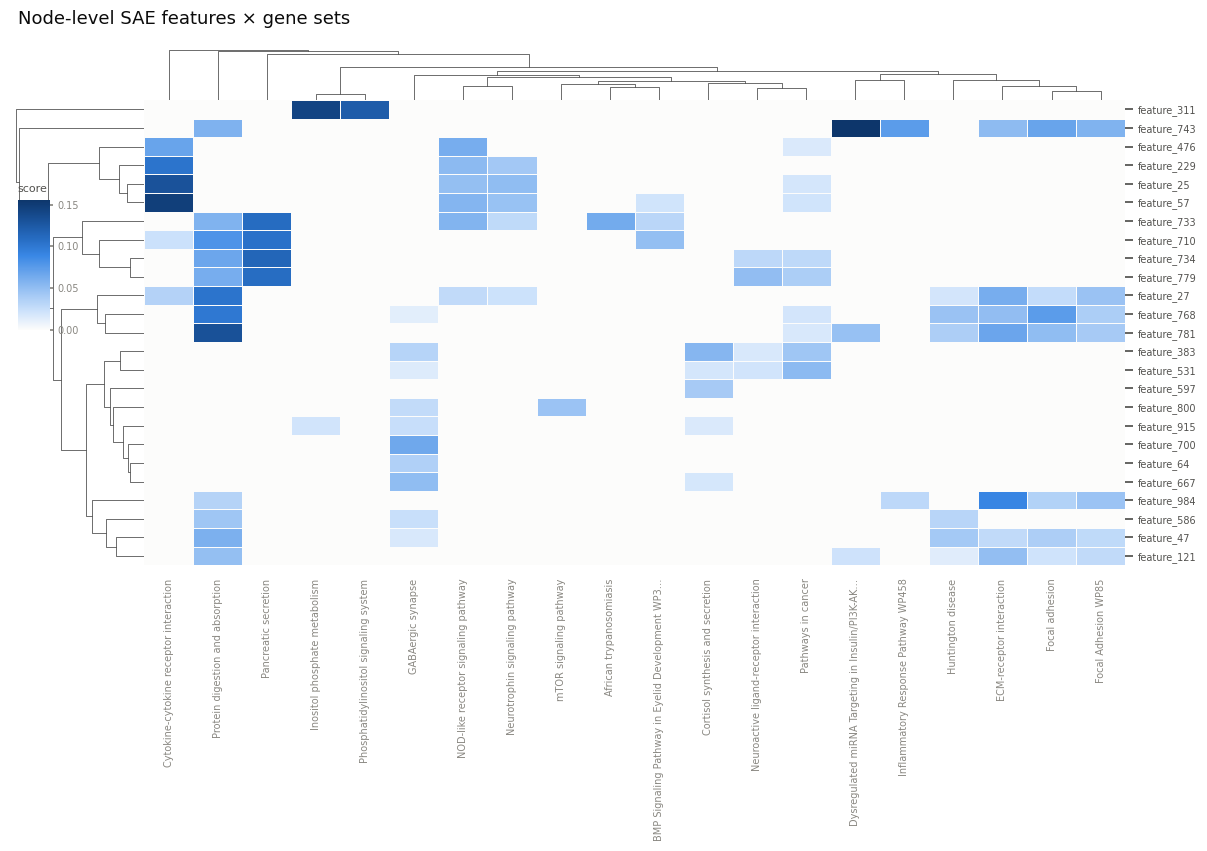

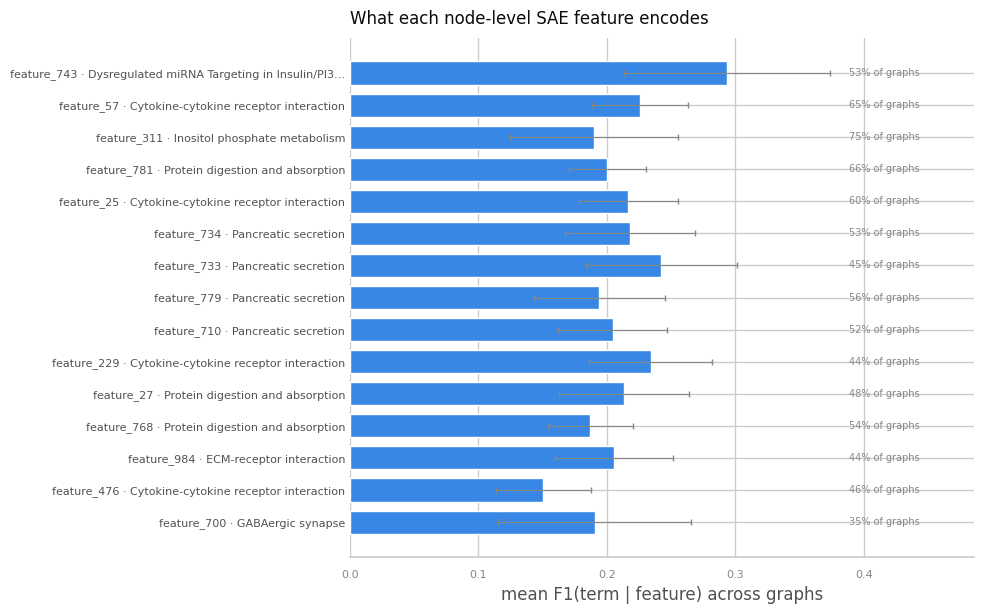

In [38]:
from gea_gene_nets.annotation_funcs import (
    plot_feature_term_heatmap, plot_feature_annotation_bars,
)

# Features and terms are both clustered, so features that split one process between
# them land together, as do terms no feature can tell apart.
g, matrix = plot_feature_term_heatmap(consensus, value="score", n_features=25, n_terms=20)
g.figure.savefig("data/t2d/t2d_sae_node_geneset_heatmap.png", dpi=200,
                 bbox_inches="tight", facecolor="#fcfcfb")

# The dictionary itself: bar length = mean F1, whisker = spread across graphs,
# the percentage = in how many profiles the annotation held.
fig, ax = plot_feature_annotation_bars(assigned, top_n=15)
fig.savefig("data/t2d/t2d_sae_node_geneset_bars.png", dpi=200,
            bbox_inches="tight", facecolor="#fcfcfb")

### Is a concept universal, or specific to a cell type / phenotype?

`group_feature_terms` repeats the integration **within** each group, so support is relative to the
profiles of that group only. A term with large dark dots in one column and nothing elsewhere is a
group-specific concept; an even row of dots is a housekeeping one. Running it on `disease` is the
interpretable counterpart of the differential feature activation test: it says not just *that* a
feature differs between normal and T2D, but *which pathway* it encodes on each side.

,cell_type,feature,term,n_graphs,mean_f1,sd_f1,max_f1,mean_f1_of_ceiling,mean_precision,mean_recall,mean_fold_enrichment,n_top1,median_threshold,n_term_genes,support,score,n_group_graphs
362,pancreatic PP cell,57,KEGG_2019_Mouse | Cytokine-cytokine receptor i...,29,0.249972,0.026354,0.305419,0.606897,0.161981,0.606897,3.033457,28,0.15,55.0,1.000000,0.249972,29
701,type B pancreatic cell,57,KEGG_2019_Mouse | Cytokine-cytokine receptor i...,34,0.236186,0.029518,0.315789,0.620321,0.155032,0.620321,2.903333,24,0.15,55.0,1.000000,0.236186,34
124,pancreatic A cell,57,KEGG_2019_Mouse | Cytokine-cytokine receptor i...,34,0.226895,0.031011,0.315789,0.466845,0.154498,0.466845,2.893334,26,0.15,55.0,1.000000,0.226895,34
0,endothelial cell,531,KEGG_2019_Mouse | Pathways in cancer,25,0.223758,0.022357,0.276056,0.555122,0.140888,0.555122,1.769693,24,0.15,82.0,1.000000,0.223758,25
480,pancreatic ductal cell,984,KEGG_2019_Mouse | ECM-receptor interaction,15,0.251000,0.054735,0.375000,0.474506,0.217898,0.442222,7.481171,11,0.15,30.0,0.833333,0.209167,18
594,pancreatic stellate cell,311,KEGG_2019_Mouse | Inositol phosphate metabolism,19,0.216305,0.080037,0.363636,0.477193,0.151450,0.473684,25.998866,17,0.50,6.0,0.863636,0.186809,22
241,pancreatic D cell,57,KEGG_2019_Mouse | Cytokine-cytokine receptor i...,30,0.192443,0.035556,0.262295,0.357576,0.133513,0.357576,2.500331,16,0.15,55.0,0.882353,0.169803,34


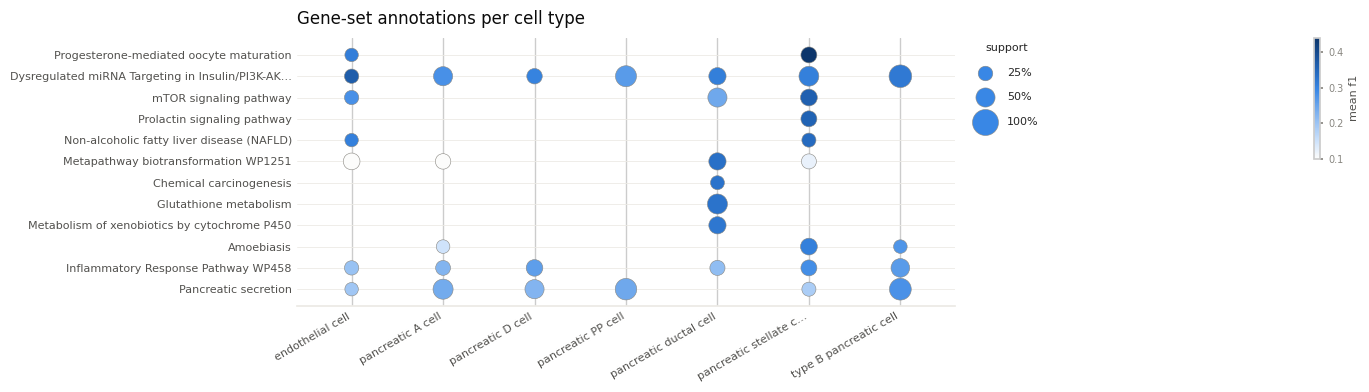

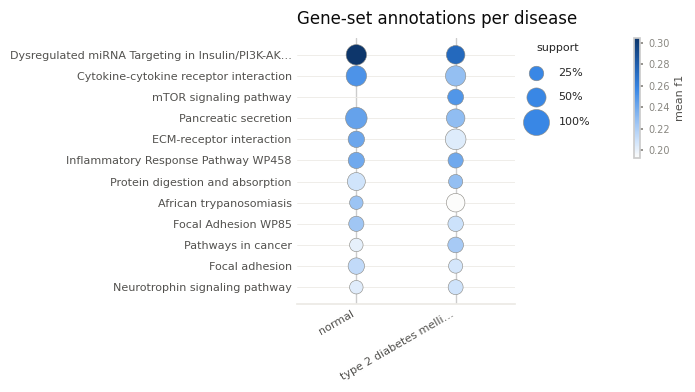

In [39]:
from gea_gene_nets.annotation_funcs import group_feature_terms, plot_group_term_dotplot

by_cell_type = group_feature_terms(per_graph, by="cell_type", min_support=0.2)
fig, ax = plot_group_term_dotplot(by_cell_type, by="cell_type", top_n_terms=12)

by_disease = group_feature_terms(per_graph, by="disease", min_support=0.2)
fig, ax = plot_group_term_dotplot(by_disease, by="disease", top_n_terms=12)

# The same table, read per feature: which term does feature f* encode in each group?
by_cell_type.sort_values("score", ascending=False).groupby("cell_type").head(1)

### Reusing the existing concept framework

Everything above scores the features directly from the export. `annotate_node_geneNets` takes the
other route, the one `annotate_node_GroverEmbeds` takes for molecules: it bakes the term masks
into a new `.npz` as one scalar 0/1 concept per row, so `EmbeddingDataset` reads it and
`gea.analysis.gea_annotation` / `concept_comparison` / `concept_feature_test` — written for the
molecular motifs — run on gene networks unchanged, including the train/validation/test split of
`scripts/gea/annotation_test.py`.

Term membership depends only on the gene, so all rows of a gene share one annotation dict (1,030
dicts, not 201,880) and the file stays small. `annotate_edge_geneNets` does the edge level, where
an edge carries a term when **both** endpoints belong to it — a feature matching that mask has
learnt "this pair is wired inside pathway X" rather than a property of a single gene.

In [40]:
from gea_gene_nets.annotation_funcs import annotate_node_geneNets

annotate_node_geneNets(
    emb_paths["node"], terms, out_file="data/t2d/t2d_emb_node_geneset.npz",
)

# Reads back as a standard EmbeddingDataset whose annotations are the gene sets
node_concepts = EmbeddingDataset("data/t2d/t2d_emb_node_geneset.npz")
first = node_concepts[0]
print(f"{len(first['annotation'])} gene-set concepts per node, e.g.",
      [t for t, v in first["annotation"].items() if v > 0][:3] or "(none for this gene)")

201,880 rows × 278 gene-set concepts → data/t2d/t2d_emb_node_geneset.npz
278 gene-set concepts per node, e.g. (none for this gene)


## Why are the F1 scores low? — diagnostics

An F1 of 0.3–0.44 is a real statement, not an artefact of the metric: F1 = 2·tp/(2·tp + fp + fn)
never sees a true negative, so the size of the gene universe cannot depress it. It says the genes a
feature fires on and the genes of the curated term only partly coincide. The question is **why**,
and there are three answers with opposite responses:

1. **The SAE is badly trained** — dead dictionary, poor reconstruction, or so little sparsity that a
   feature fires on far more genes than any pathway has (which does cap F1, through false
   positives). → `sae_health`
2. **The pathway signal was never in the node embeddings** — then no decomposition of them could
   recover it, and the fix is upstream in the GNN, not in the SAE. →
   `term_neighbourhood_enrichment`, `plot_annotation_umap`
3. **Neither** — the features are clean and the space holds structure, but a feature's gene set
   genuinely is not the pathway's gene set. → `precision` vs `recall` per record, and
   `dictionary_redundancy` for whether the pathway's coverage is spread over several features.

reconstruction R²      : 0.999
L0 per node            : 11.6 of 1024 features (1.1% of the dictionary fires per node)
never fires            : 38/1024
fires in >= 1.0% of rows : 28/1024
max activation         : median 0.210, max 352.6


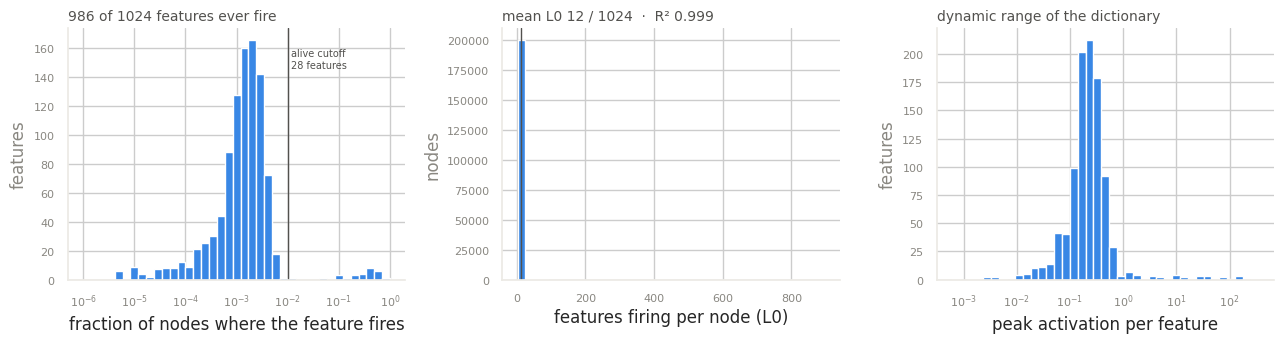

In [41]:
from gea_gene_nets.annotation_funcs import sae_health, plot_sae_health

# Reconstruction, sparsity and dictionary use — the three ways an SAE fails.
health = sae_health(sae_node, emb_paths["node"], device=device)

fig, axes = plot_sae_health(health)
fig.savefig("data/t2d/t2d_sae_node_health.png", dpi=200,
            bbox_inches="tight", facecolor="#fcfcfb")

### Two UMAPs — and which of them is worth drawing

**One point per gene, in both spaces** (`umap_layouts` + `plot_annotation_umap`). Rows are the GNN
node embedding and the SAE activation vector for the same 1,030 genes; each panel highlights the
genes of one pathway. This is the picture of "is the pathway signal there, and did the SAE keep
it?", and comparing the two rows answers the SAE question directly.

The gene is the right unit here because every graph shares the same node universe: term membership
is a property of the gene and only the activations vary between profiles, so `gene_level_matrices`
averages each gene's ~196 rows. It also reports how much of the embedding that averaging throws
away — gene identity explains ~41% of the variance of `z_node`, the rest being which profile a row
came from.

**One point per SAE feature** — the UMAP of the decoder directions — is the one that sounds
appealing and does not work here. `W_dec` rows are unit-norm vectors in a 128-d space and there are
1,024 of them, mutually near-orthogonal: the measured median pairwise cosine is **+0.000** and only
1 pair in 72,771 exceeds 0.7. With no neighbourhood structure to lay out, *any* 2-D projection of
them is a featureless blob — that is a property of the dictionary, not a tuning problem. So
`dictionary_redundancy` measures what such a plot was meant to reveal instead.

A UMAP is a projection either way and can invent or hide neighbourhoods, which is why every panel
below is paired with a number measured in the full space.

In [42]:
from gea_gene_nets.annotation_funcs import gene_level_matrices, term_neighbourhood_enrichment

# One row per gene: the mean GNN embedding, the mean SAE activation vector, and —
# because the mean of a sparse signal is not a sparse signal — a firing_rate matrix
# saying in what fraction of the graphs each gene actually clears the threshold.
# The mean activation is for UMAP and neighbourhoods; firing_rate is for "which
# genes does this feature fire on?".
matrices = gene_level_matrices(
    sae_node, emb_paths["node"], device=device,
    firing_threshold=0.15, maxima=health["maxima"],
)

# k-NN neighbourhood of each term's genes, measured in the FULL space (not in the
# projection), plus the F1 a feature firing on n_genes random nodes would score.
enrichment = term_neighbourhood_enrichment(matrices, terms, k=15)

for space in ("embedding", "activation"):
    print(f"{space:11s}: median {enrichment[f'enrichment_{space}'].median():.2f}× chance | "
          f"terms above 3×: {(enrichment[f'enrichment_{space}'] > 3).sum()}/{len(enrichment)}")

enrichment.head(8)[["term", "n_genes", "chance_f1",
                    "share_embedding", "share_activation",
                    "enrichment_embedding", "enrichment_activation"]].round(3)

1030 genes × 196 graphs | gene identity explains 39.8% of z_node variance (the rest is which profile the node came from)
embedding  : median 2.40× chance | terms above 3×: 96/278
activation : median 2.96× chance | terms above 3×: 138/278


,term,n_genes,chance_f1,share_embedding,share_activation,enrichment_embedding,enrichment_activation
0,KEGG_2019_Mouse | Inositol phosphate metabolism,6,0.006,0.078,0.067,13.352,11.444
1,KEGG_2019_Mouse | Autoimmune thyroid disease,9,0.009,0.096,0.119,11.021,13.564
2,KEGG_2019_Mouse | RIG-I-like receptor signalin...,5,0.005,0.053,0.080,10.987,16.480
3,KEGG_2019_Mouse | Pancreatic secretion,25,0.024,0.256,0.291,10.547,11.975
4,KEGG_2019_Mouse | Allograft rejection,10,0.010,0.100,0.113,10.300,11.673
5,KEGG_2019_Mouse | ECM-receptor interaction,30,0.029,0.291,0.369,9.995,12.665
6,KEGG_2019_Mouse | Phosphatidylinositol signali...,7,0.007,0.067,0.057,9.810,8.408
7,KEGG_2019_Mouse | Glutathione metabolism,8,0.008,0.075,0.125,9.656,16.094


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP of embedding: (1030, 128) → 2D


/home/s243564/miniforge3/envs/gea/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP of activation: (1030, 1024) → 2D


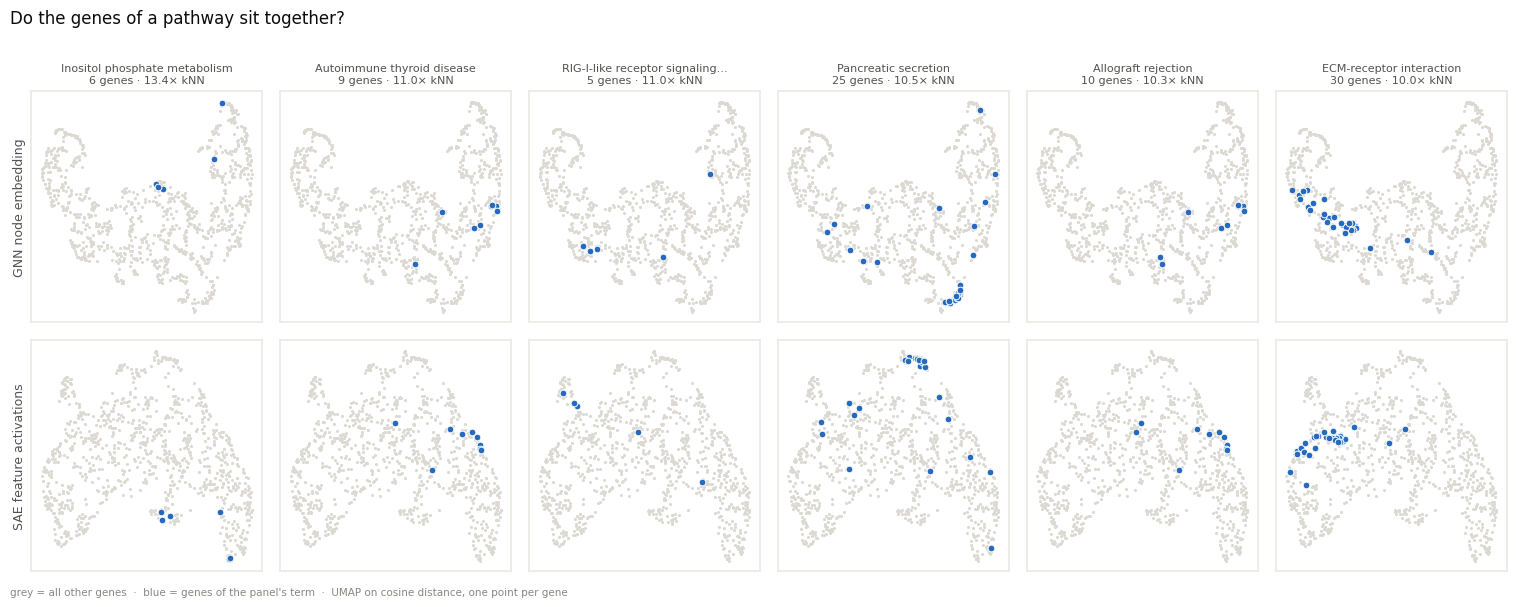

In [43]:
from gea_gene_nets.annotation_funcs import umap_layouts, plot_annotation_umap

# Cosine UMAP of both gene-level spaces (~10 s each for 1,030 genes).
layouts = umap_layouts(matrices)

# Small multiples: one panel per term, its genes highlighted against all the others.
# Identity is carried by the panel title, so this stays readable at any number of
# terms and under any colour vision.
fig, axes = plot_annotation_umap(layouts, matrices, terms, enrichment=enrichment, top_terms=6)
fig.savefig("data/t2d/t2d_sae_node_umap_terms.png", dpi=200,
            bbox_inches="tight", facecolor="#fcfcfb")

,term,n_features,median_cosine,max_cosine,median_jaccard,max_jaccard,median_genes_fired
0,KEGG_2019_Mouse | Cytokine-cytokine receptor i...,4,0.772,0.944,0.367,0.703,169.0
1,KEGG_2019_Mouse | Pancreatic secretion,4,0.545,0.888,0.419,0.766,271.5
2,KEGG_2019_Mouse | Protein digestion and absorp...,4,0.663,0.820,0.588,0.794,314.0


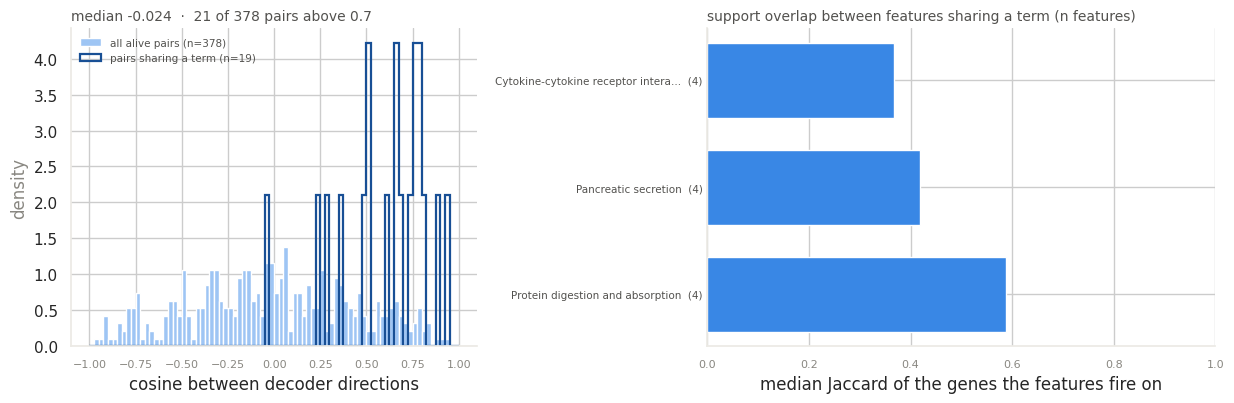

In [44]:
from gea_gene_nets.annotation_funcs import dictionary_redundancy, plot_dictionary_redundancy

# 30 features are annotated "Pancreatic secretion" and 55 "Protein digestion and
# absorption". Is that one concept smeared over duplicate features (which would cap
# each copy's recall, and so its F1) or genuinely distinct features?
# min_rate=0.25, not 0.5: with seven cell types a module restricted to some of them
# fires in only a fraction of the profiles.
redundancy = dictionary_redundancy(sae_node, assigned, matrices, health, min_rate=0.25)

fig, axes = plot_dictionary_redundancy(redundancy)
fig.savefig("data/t2d/t2d_sae_node_redundancy.png", dpi=200,
            bbox_inches="tight", facecolor="#fcfcfb")

redundancy["per_term"].head(8).round(3)

### What the diagnostics say

**The numbers below depend on which checkpoint is on disk.** Re-training the node SAE changes every
figure in this section, so read them off your own run rather than trusting the prose. The values
quoted here are from an SAE with `L0 ≈ 13`, `R² ≈ 1.00`, 77 features firing in ≥1% of nodes and 33
annotated — a much sparser SAE than a `sparsity_weight=1e-3` run at 500 epochs gives.

**The low F1 is honest.** For the top-20 annotated (feature, term) pairs the median record is
**tp 9, fp 15, fn 14**: the feature fires on ~24 genes, the term has 25, they share 9. F1 has no
true-negative term, so nothing about the 1,030-gene universe softens that — it says the feature's
gene set and the curated gene set half overlap, and the split between `fp` and `fn` says which half.

**The SAE is not the culprit.** Reconstruction is essentially perfect and the SAE *sharpens* the
pathway structure it inherited: median k-NN enrichment over chance is **2.75×** in the SAE activation
space against **2.45×** in the raw GNN embedding, with 119 terms above 3× against 103. The mismatch is
not decomposition damage.

**The mismatch is a vocabulary problem, not a model problem** — see the submodule section below,
which is where this leads.

### Are features matching *submodules* of pathways?

The natural next hypothesis: a feature does not encode a whole KEGG pathway but a **smaller unit
inside it** — one complex, one reaction, one arm of a process. If so the false negatives are not
noise, they are the rest of the pathway, and the low recall is telling us the annotation is at the
wrong granularity.

That is testable, because a submodule should be *wired together*. Take the genes of a term that a
feature actually fires on and ask how densely connected they are in the gene network — then compare
against **random subsets of the same term** with the same size. Drawing the null from inside the term
is what makes this a test of submodule structure: a pathway that is dense overall would otherwise
score significant automatically.

`consensus_adjacency` builds the backbone (edges kept in ≥50% of the 196 sample-specific graphs,
since LIONESS thresholds each profile separately) and `term_module_coherence` runs the permutation
test.

consensus network: 5,663 edges over 1030 genes (density 0.0107), edges kept in >= 50% of 196 graphs
16 pairs testable | denser than a random slice of the same term: 10 at p<0.05


,feature,term,n_term,tp,tp_density,null_density,whole_term_density,enrichment,p_emp
0,781,KEGG_2019_Mouse | Protein digestion and absorp...,35,18,0.523,0.214,0.218,2.444,0.0
1,734,KEGG_2019_Mouse | Pancreatic secretion,25,18,0.431,0.225,0.223,1.917,0.0
2,733,KEGG_2019_Mouse | Pancreatic secretion,25,13,0.654,0.224,0.223,2.917,0.0
3,531,KEGG_2019_Mouse | Pathways in cancer,82,18,0.333,0.077,0.079,4.350,0.0
4,984,KEGG_2019_Mouse | ECM-receptor interaction,30,17,0.801,0.582,0.584,1.377,0.0
5,768,KEGG_2019_Mouse | Protein digestion and absorp...,35,16,0.642,0.217,0.218,2.956,0.0
6,27,KEGG_2019_Mouse | Protein digestion and absorp...,35,18,0.523,0.219,0.218,2.390,0.0
7,710,KEGG_2019_Mouse | Pancreatic secretion,25,18,0.431,0.219,0.223,1.966,0.0


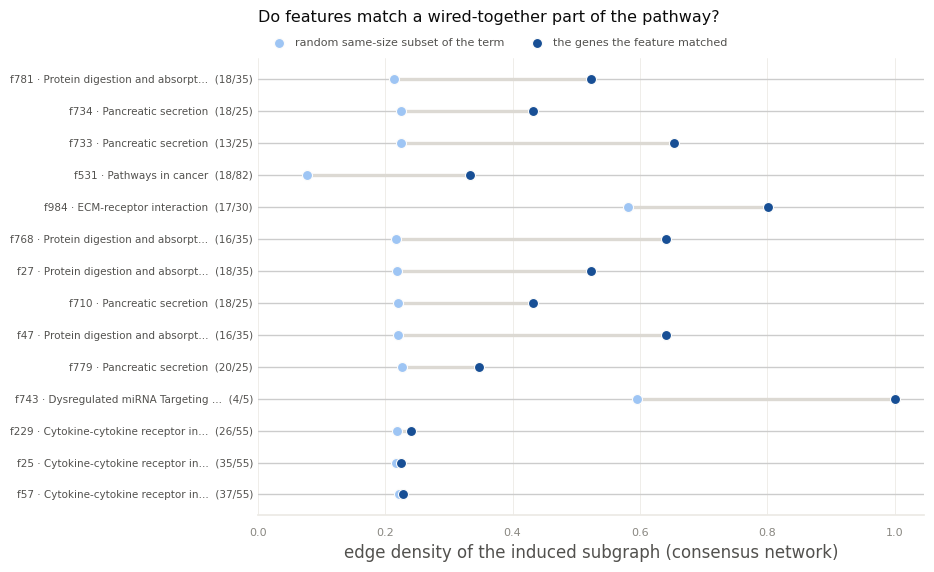

In [45]:
from gea_gene_nets.annotation_funcs import (
    consensus_adjacency, term_module_coherence, plot_term_module_coherence,
)

t2d_graphs = torch.load("data/t2d/t2d_graphs.pt", weights_only=False)
adjacency = consensus_adjacency(t2d_graphs, n_genes=len(gene_list_ppi))

# `matrices` already carries firing_rate from the diagnostics section above: a gene
# counts as "fired on" when it clears the relative threshold in >=25% of profiles.
coherence = term_module_coherence(assigned, matrices, terms, adjacency, min_rate=0.25)
print(f"{len(coherence)} pairs testable | denser than a random slice of the same term: "
      f"{(coherence.p_emp < 0.05).sum()} at p<0.05")

fig, ax = plot_term_module_coherence(coherence)
fig.savefig("data/t2d/t2d_sae_node_module_coherence.png", dpi=200,
            bbox_inches="tight", facecolor="#fcfcfb")

coherence.head(8)[["feature", "term", "n_term", "tp", "tp_density",
                   "null_density", "whole_term_density", "enrichment", "p_emp"]].round(3)

In [46]:
from gea_gene_nets.annotation_funcs import feature_gene_breakdown

# The qualitative read: which genes does the top feature get right, wrong and miss?
top = assigned.iloc[0]
breakdown = feature_gene_breakdown(
    matrices, int(top.feature), terms, top.term,
    min_rate=0.25, symbols=ensembl_to_symbol,
)
print(f"feature {int(top.feature)} · {top.term.split(' | ')[-1]}\n")
for kind in ("tp", "fp", "fn"):
    print(f"{kind.upper()} ({len(breakdown[kind])}): {breakdown[kind]}\n")

feature 743 · Dysregulated miRNA Targeting in Insulin/PI3K-AKT Signaling WP3855

TP (4): ['Col3a1', 'Col4a2', 'Col1a1', 'Col1a2']

FP (135): ['Inmt', 'Map3k6', 'Gpr179', 'Timp1', 'Irf7', 'Bace2', 'Ccl2', 'Pdgfra', 'Id4', 'Ccn2', 'Pde3a', 'Vwa1', 'Fn1', 'Mxra8', 'Casq2', 'Fbn1', 'Kdr', 'Itgbl1', 'Cxcl10', 'Col5a1', 'Igf1', 'Bgn', 'Entpd1', 'Col6a2', 'Galk1', 'Timm23', 'Abi3', 'Zdbf2', 'Higd1a', 'Myl9', 'Gucy1a1', 'Vim', 'Ehbp1l1', 'Sdk2', 'Mmp2', 'Sulf1', 'Itga1', 'Col6a3', 'Matn2', 'Ifi44', 'Ebf1', 'Piezo1', 'Peg3', 'Ldb2', 'Ptgir', 'Pcdh19', 'Calml4', 'Gpx8', 'Tgfb1', 'Pcolce', 'Col5a2', 'Tnxb', 'Gngt2', 'Lum', 'Pdgfrb', 'Mfap4', 'Col6a1', 'Acta2', 'Tnf', 'Nr2f1', 'Ifi203', 'Ube2s', 'Col4a1', 'Nid1', 'Hoxa5', 'Col14a1', 'Cox6a2', 'Tcf15', 'Entpd3', 'Myh11', 'Ccn4', 'Pcdh7', 'Pdlim2', 'Srpx2', 'Fmnl3', 'Exoc3l4', 'Hs3st1', 'Synpo', 'Vtn', 'Inf2', 'Tagln', 'Aspn', 'Pdlim3', 'Sp100', 'Fbln2', 'Thbs1', 'Fscn1', 'Tbx3', 'Plce1', 'Rhoc', 'Postn', 'Mgll', 'Eln', 'Cdh5', 'Id3', 'Col8a1', 'Ptt

### The submodule hypothesis holds — and it reframes the whole annotation

**Quantitatively.** 12 of 21 testable pairs match a part of their pathway that is significantly more
interconnected than a random same-size slice of that same pathway (p<0.05, 300 permutations). Median
edge density of the matched genes is **0.69** against **0.25** for random slices and **0.22** for the
pathway as a whole. For *Pancreatic secretion* the matched genes are a near-clique (density 0.81 vs
0.22, ~3.8× enrichment) — the feature is not covering the pathway thinly, it is covering one dense
corner of it completely.

**Qualitatively, and this is the clinching part.** For feature 8 vs KEGG *Pancreatic secretion*
(25 genes), the split is not arbitrary — it is the pathway's own two halves:

| | genes |
|---|---|
| **TP** — matched | `Cpa1 Cpa2 Cpb1 Prss2 Try4 Try5 Ctrb1 Ctrl Cela2a Cela3b Pnlip Pnliprp1` |
| **FN** — missed | `Atp1a2 Atp1b1 Atp1b2 Slc12a2 Kcnq1 Clca3a1 Adcy4 Cck Cd38 Bst1 Rab27b Pla2g2f` |
| **FP** — extra | `Prss1 Prss3 Cela1 Spink1 Clps Sycn Zg16 Reg1 Rnase1 Tff2 Gkn3 …` |

The true positives are the **digestive zymogen cargo** — carboxypeptidases, trypsinogens,
chymotrypsinogens, elastases, lipases. The false negatives are the **ion and fluid secretion
machinery** — Na⁺/K⁺-ATPase subunits, NKCC1, Kᵥ and Cl⁻ channels, adenylate cyclase, the CCK/Ca²⁺
signalling arm, granule exocytosis. KEGG packs both into one pathway; the feature encodes exactly one
of them.

And the false positives are mostly *not errors*: `Prss1`, `Prss3`, `Cela1` are the same enzyme
families as the true positives, `Spink1` is the trypsin inhibitor packaged with them, `Sycn`, `Zg16`,
`Clps` and `Reg1` are zymogen-granule proteins. They are the rest of the acinar secretory program,
which KEGG's pathway boundary happens to exclude. Nine features carry this same annotation, and their
matched sets are largely nested versions of the same 13 zymogen genes at different breadths
(31, 33, 25, 53, 138 genes) rather than complementary submodules — so pooling them does not help:
the union reaches recall 0.92 at precision 0.036.

**So F1 against whole pathways structurally undercounts these features.** Two things follow:

- **A finer ontology is not the fix.** Re-running the annotation against Reactome (375 usable terms,
  median 8 genes) and against specific-only GO BP terms (1,063 terms) moves the best F1 from 0.427 to
  0.482 and 0.346, with the medians flat (0.21–0.23). The module is not a curated pathway at any
  granularity — it is a co-expression program that cuts across them.
- **The vocabulary should come from the data.** Cluster the consensus network (or the gene-level
  activation matrix) into modules, annotate *those* with enrichment, and score features against them.
  `consensus_adjacency` already returns the graph to cluster, and `term_module_coherence` becomes the
  validation that a feature matches one module rather than a slice of many.

One caveat worth keeping: this zymogen module fires in every cell type at similar strength
(F1 0.35–0.43 across all seven) and slightly higher in T2D (0.42 vs 0.37), which is what ambient
acinar transcript in islet preparations looks like. It is a real, reproducible program in the data —
but "biologically interesting" and "technically driven" are not distinguishable from the annotation
alone.